In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('wine_quality_merged.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [3]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


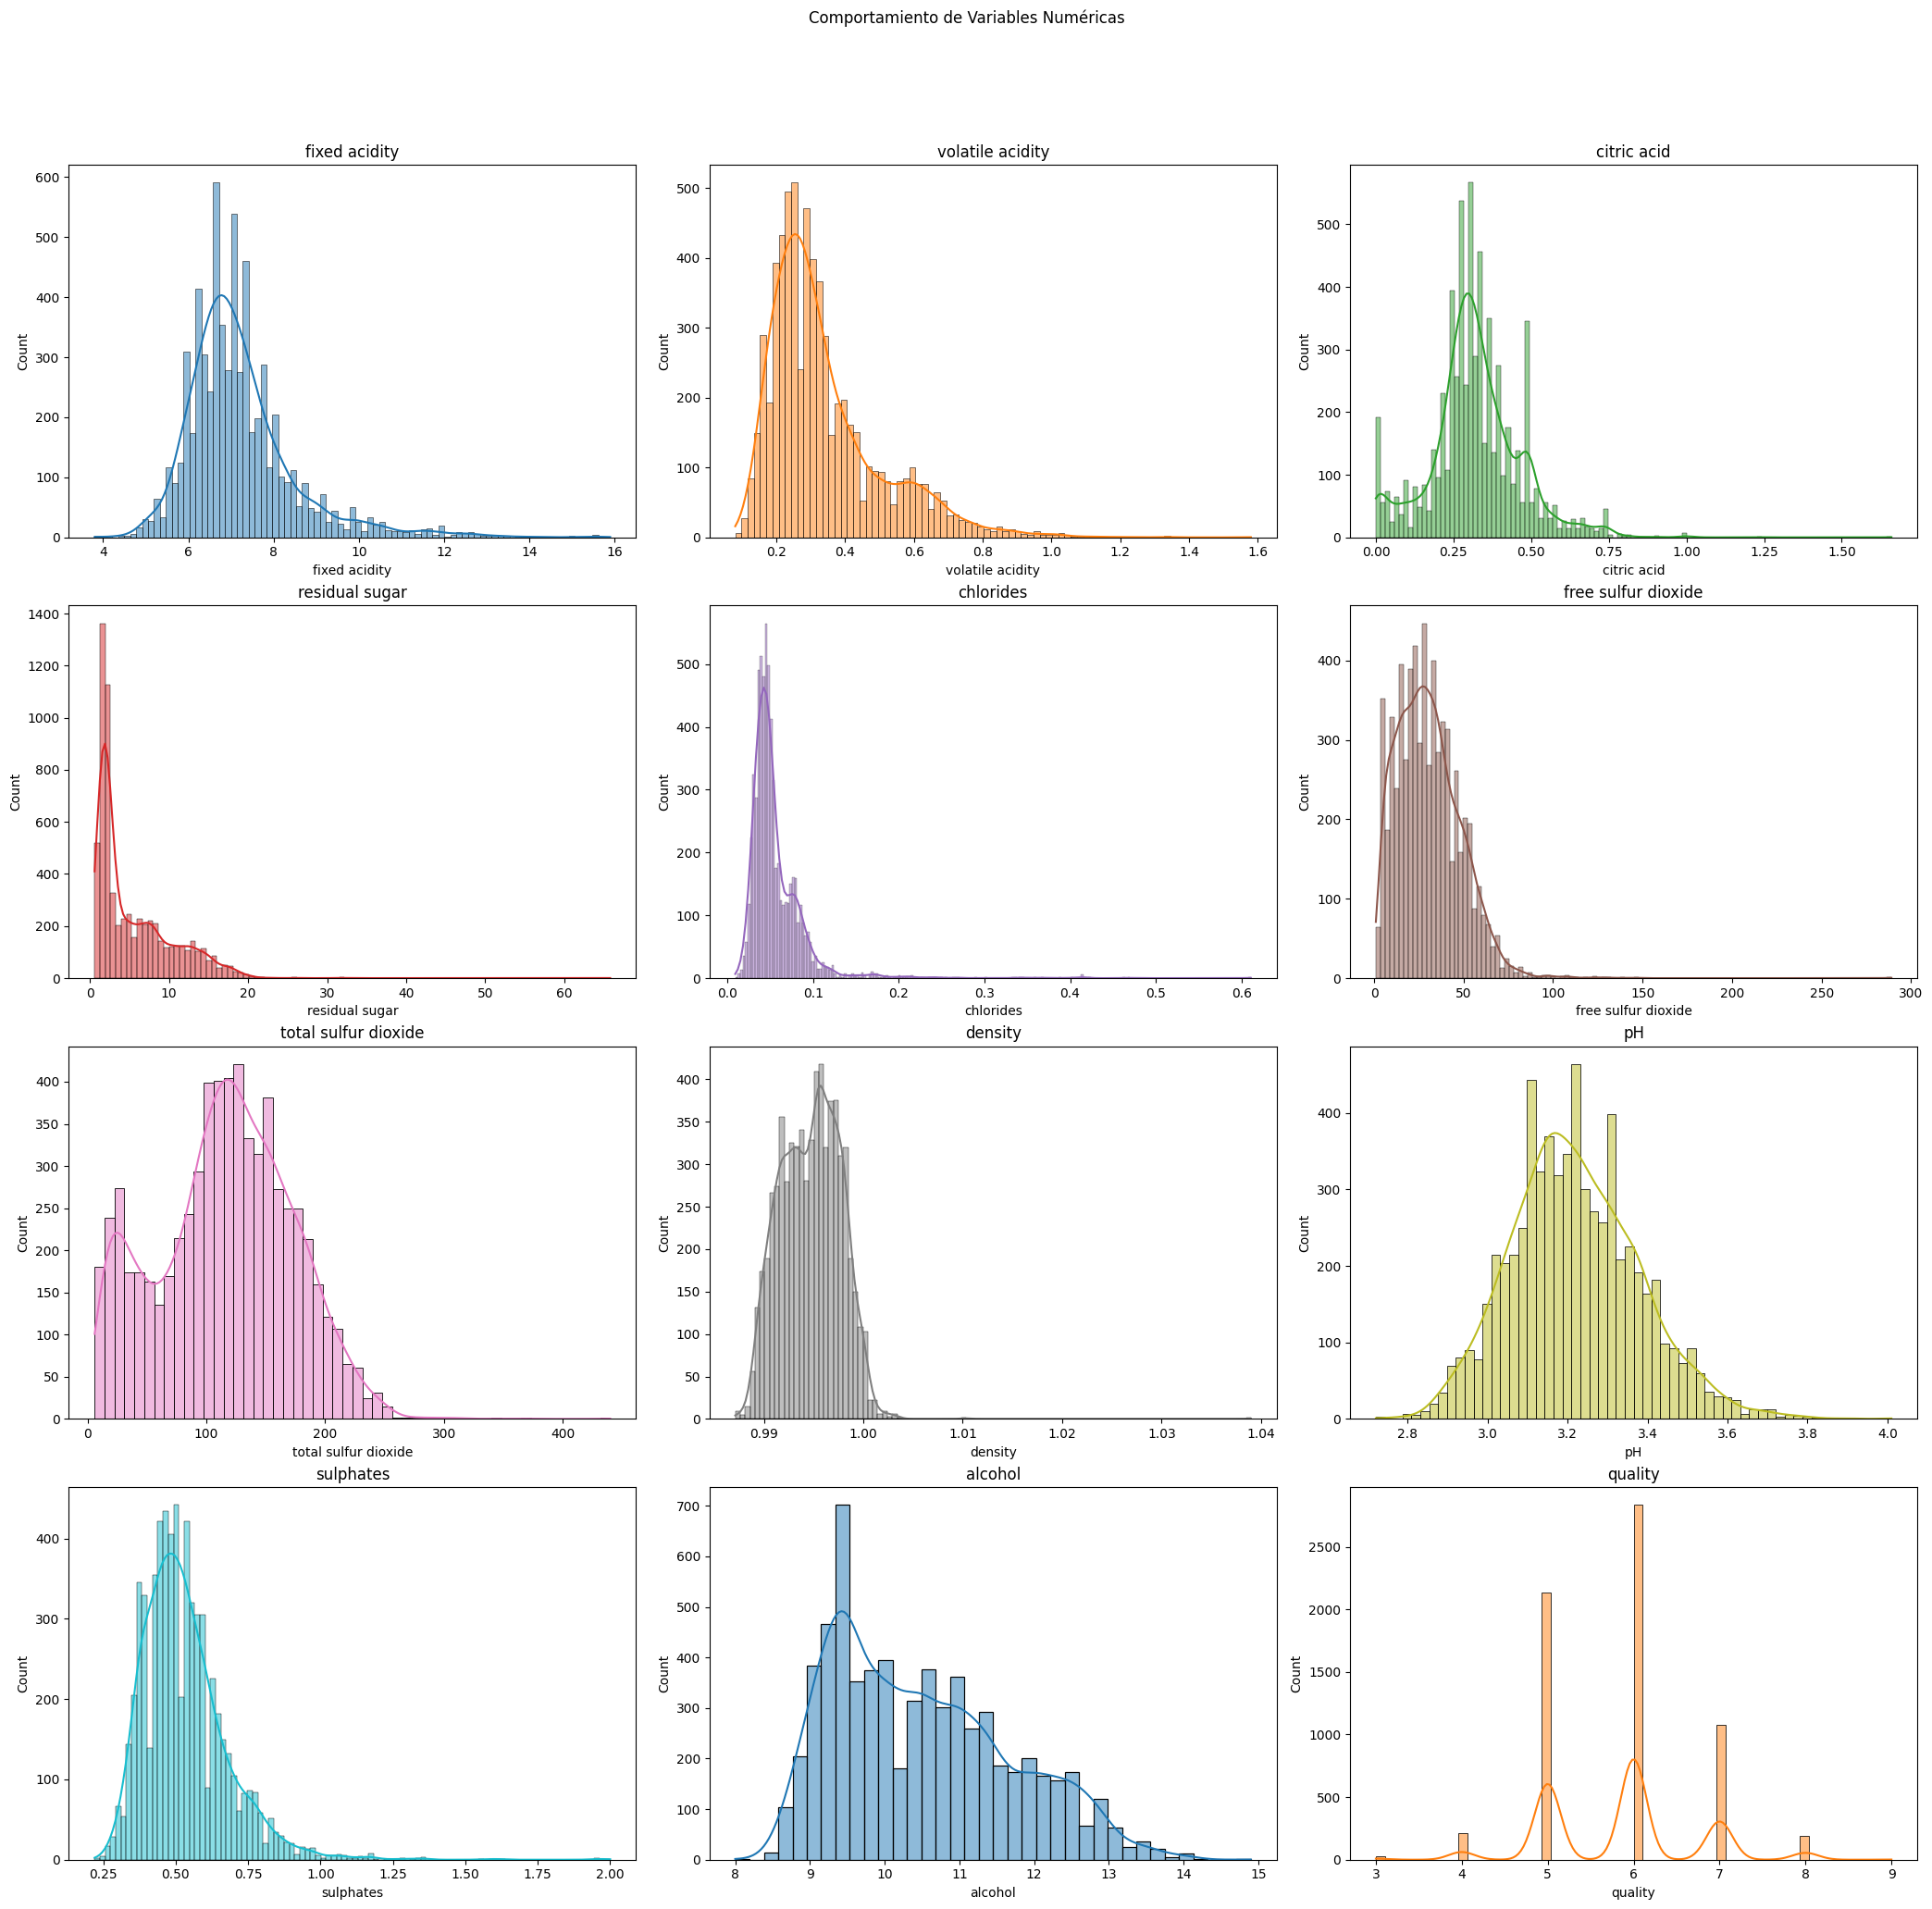

In [4]:
#Gráficos de Histogramas de frecuencia
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data = data, x = col, kde = True,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

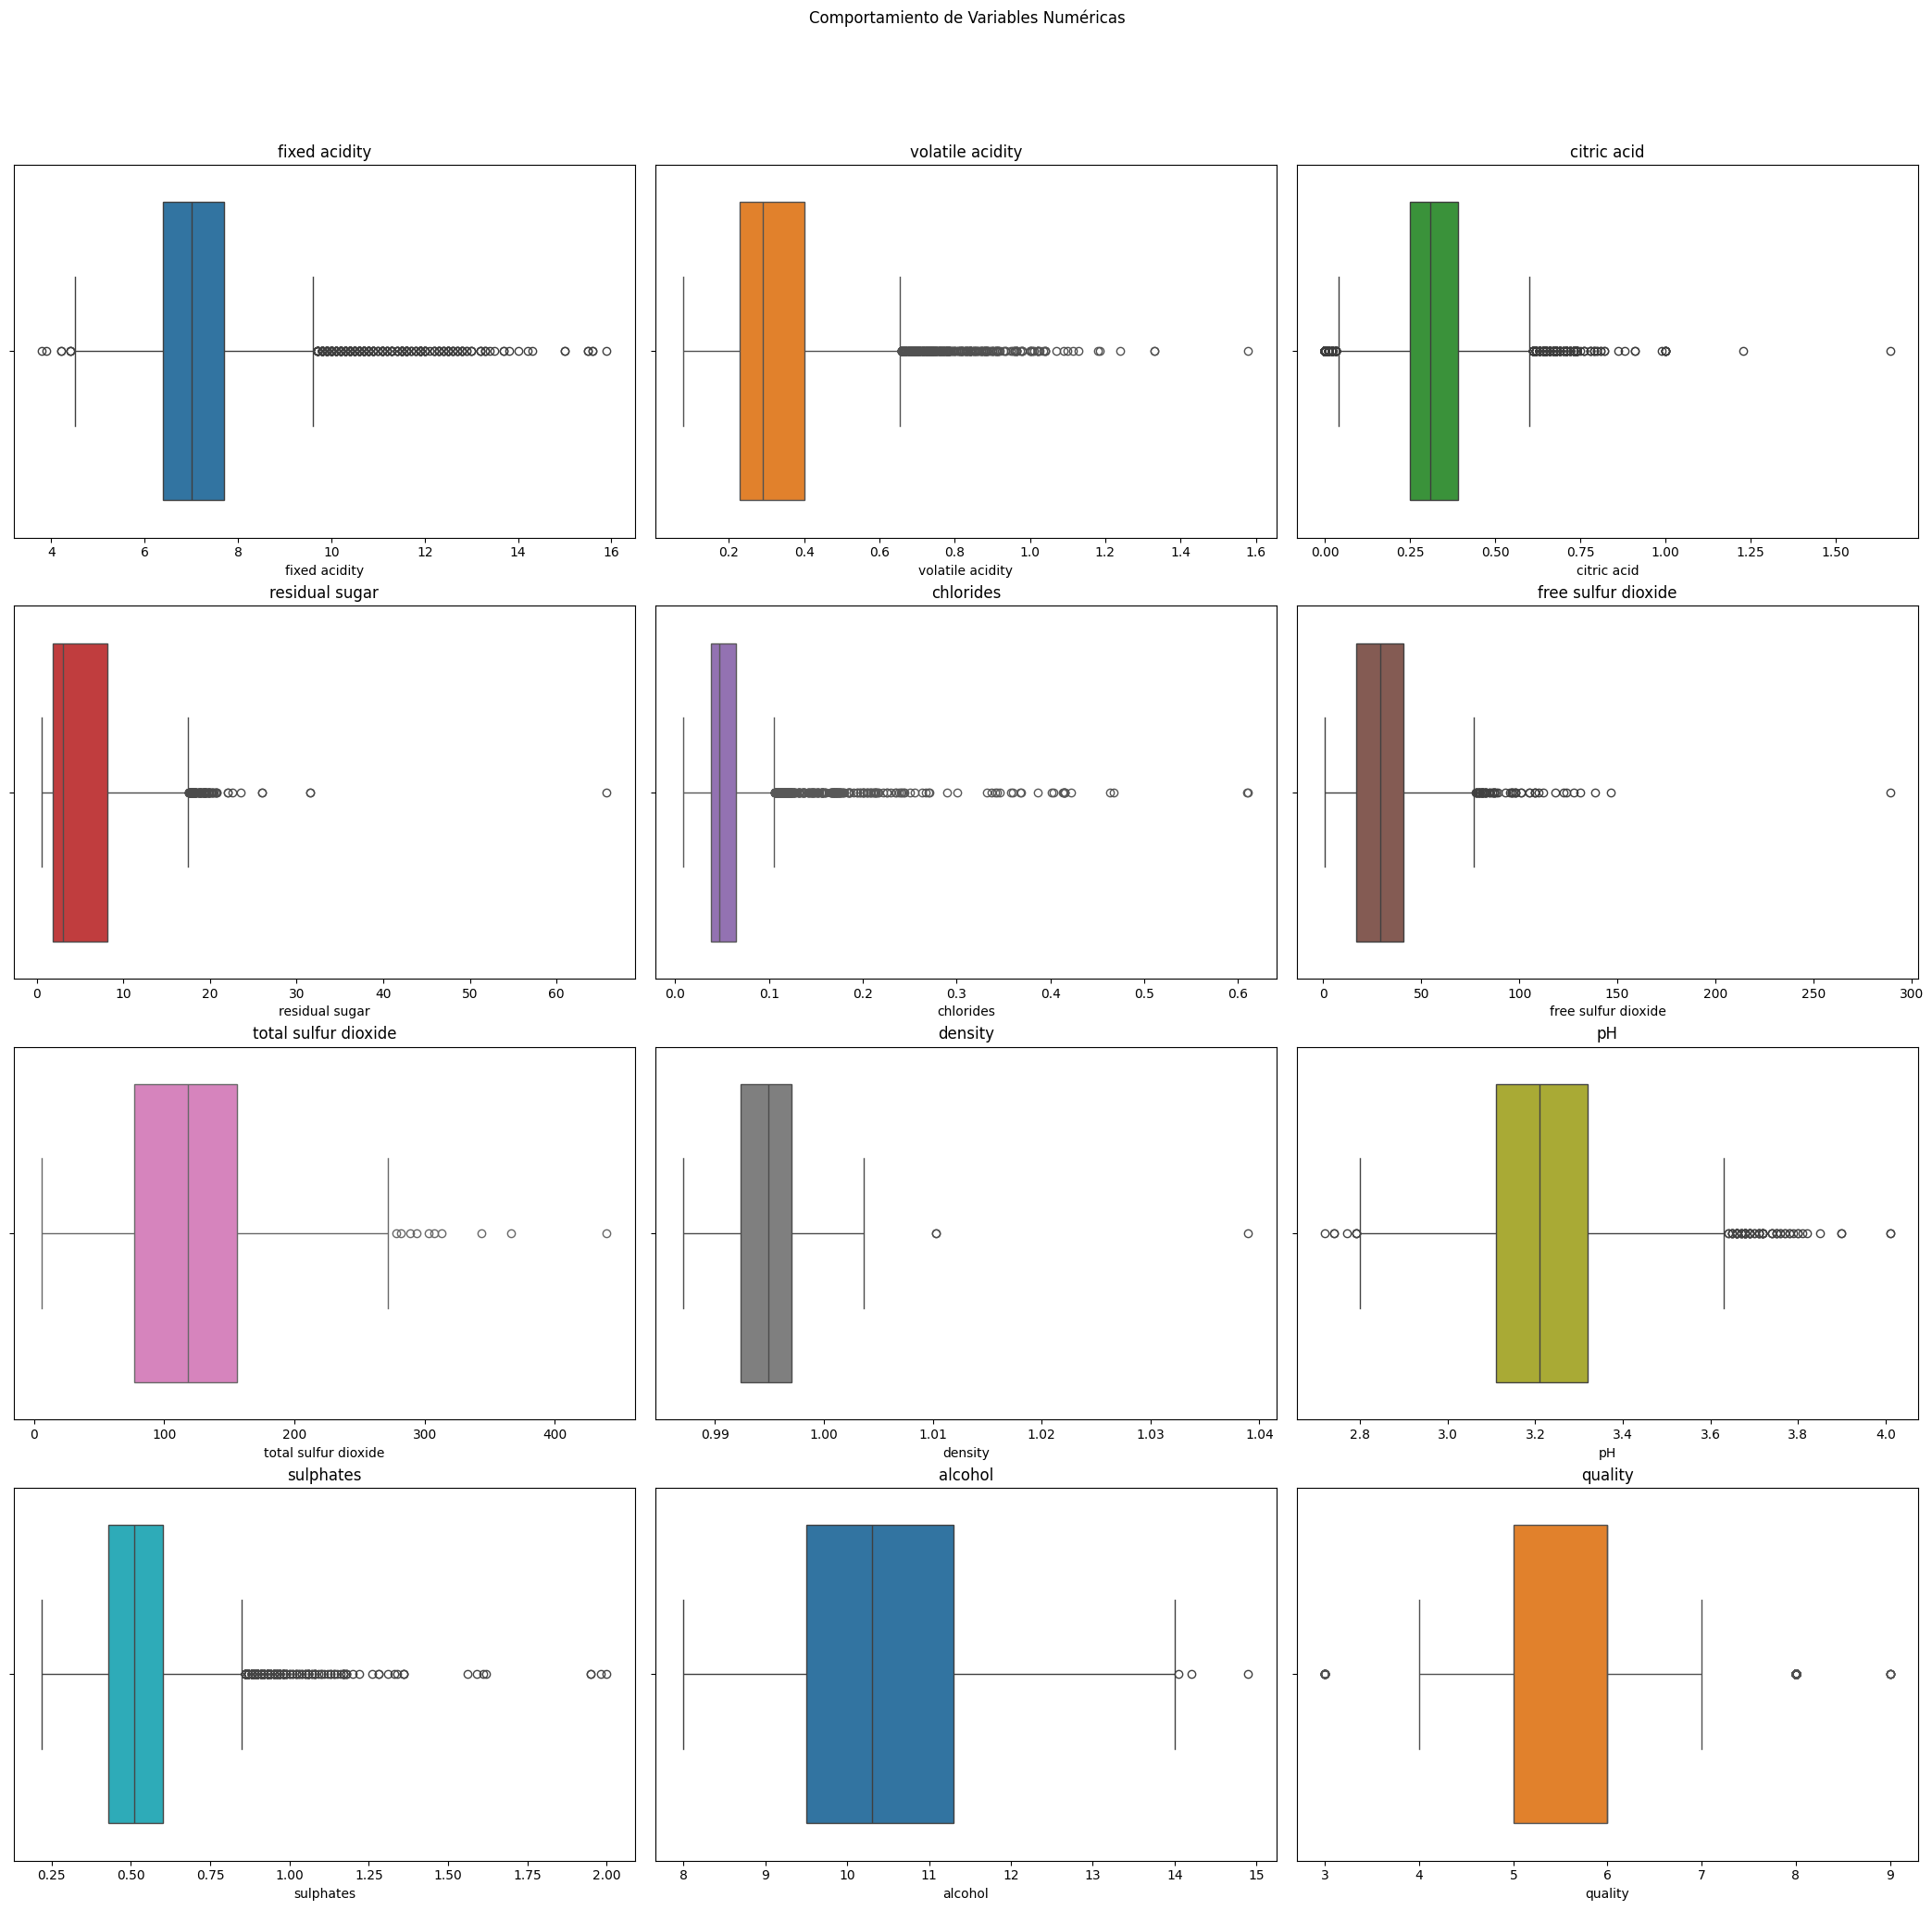

In [5]:
#Gráficos de Histogramas de frecuencia
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.boxplot(data = data, x = col,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

  ## Entendimiento de los datos:
- `fixed acidity`b: No tiene nulos implícitos porque según lo investigado, el valor máximo que tenemos de 15.9 es posible y representa un vino "ácido", que puede corresponder a algunos vinos de clima frio o a los que se les tuvo que añadir ácido para equilibrar el alto contenido en ázucar.
- `volatile acidity`: También dijimos que no tiene nulos implícitos porque a pesar de que el máximo permitido normalmente está entre 1.2g/L y 1.5g/L, hay algunas excepciones cuando el vino tiene alta azucar residual, donde volatile acidity puede llegar hasta 2.1g/L. Y el valor mínimo de 0.08 también es posible e indica una fermentación muy limpia, entonces también es un atípico natural.
- `citric acid`: Después de investigar, nos encontramos con que por ley, el máximo admisible es de 1g/L, entonces teniendo esto en cuenta y que solo eran dos valores que sobrepasaban el 1g/L, decidimos volverlos nulos explícitos.
- `residual sugar`: Del valor de ázucar residual hubo un único valor extremo que consideramos outlier antinatural, porque bajo el dataset, que se tratan vinos más tipo seco y semiseco, un valor tan alto no tiene sentido.
- `chlorides`: En esta concluimos que los atípicos eran naturales, porque según lo investigado, el límite máximo permitido es generalmente de 1g/L, que en nuestro caso, ningún dato sobrepasa esto.
- `free sulfur dioxide`: Para este vimos que los marcos legales dependían mucho del país, la mayoría rondando por los 70 y algo, pero el más alto que vimos fue de 80ppm, por tanto decidimos asumir como nulos, todos los que exedieran este valor. Y también de lo que vimos, valores muy altos rondando los 100ppm podrían estar hablando de barriles, en vez de vino terminado.
- `total sulfur dioxide`: Para esta variable cogimos el límite máximo legal permitido en Estados Unidos, que es de 350ppm, los dos valores que lo sobrepasaron, los convertimos a nulos.
- `density`: Aunque lo usual es que este entre 0.99g/mL a 0.995g/mL, al inicio de la fermentación pueden alcanzar a valores entre 1.09g/mL a 1.1g/mL y que los vinos dulces pueden tener una densidad más alta por los rangos de 1.05g/mL a 1.07g/mL, lo que hacía a nuestros atípicos posibles.
- `pH`: A pesar de que lo normal, es que el pH oscile entre 2.9 y 4, los outliers que tuvimos se acercaban mucho a estos valores \"que son lo normal\" y eran posibles.
- `sulphates`: Decidimos convertir a nulos los valores cercanos a 2g/L porque exceden el límite legal.
- `alcohol`: No decidimos eliminar ningún valor de alcohol porque el porcentage máximo es del 15%, mientras que nuestro valor máximo es 14.9%.

In [6]:
data_mod = data.copy()
data_mod.loc[data_mod['citric acid'] > 1, 'citric acid'] = np.nan
data_mod.loc[data_mod['residual sugar'] > 60, 'residual sugar'] = np.nan
data_mod.loc[data_mod['free sulfur dioxide'] > 80, 'free sulfur dioxide'] = np.nan
data_mod.loc[data_mod['total sulfur dioxide'] > 350, 'total sulfur dioxide'] = np.nan
data_mod.loc[data_mod['sulphates'] > 1.75, 'sulphates'] = np.nan
data_mod = data_mod.dropna()
data_mod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6439 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6439 non-null   float64
 1   volatile acidity      6439 non-null   float64
 2   citric acid           6439 non-null   float64
 3   residual sugar        6439 non-null   float64
 4   chlorides             6439 non-null   float64
 5   free sulfur dioxide   6439 non-null   float64
 6   total sulfur dioxide  6439 non-null   float64
 7   density               6439 non-null   float64
 8   pH                    6439 non-null   float64
 9   sulphates             6439 non-null   float64
 10  alcohol               6439 non-null   float64
 11  quality               6439 non-null   int64  
 12  type                  6439 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 704.3+ KB


In [7]:
pct_perdido = (6497 - 6439)/6497 * 100
print(f'El porcentaje de datos perdidos es: {pct_perdido:.2f}%, que es menor al 10% permitido, entonces se puede continuar y no hay necesidad de imputar.')

El porcentaje de datos perdidos es: 0.89%, que es menor al 10% permitido, entonces se puede continuar y no hay necesidad de imputar.


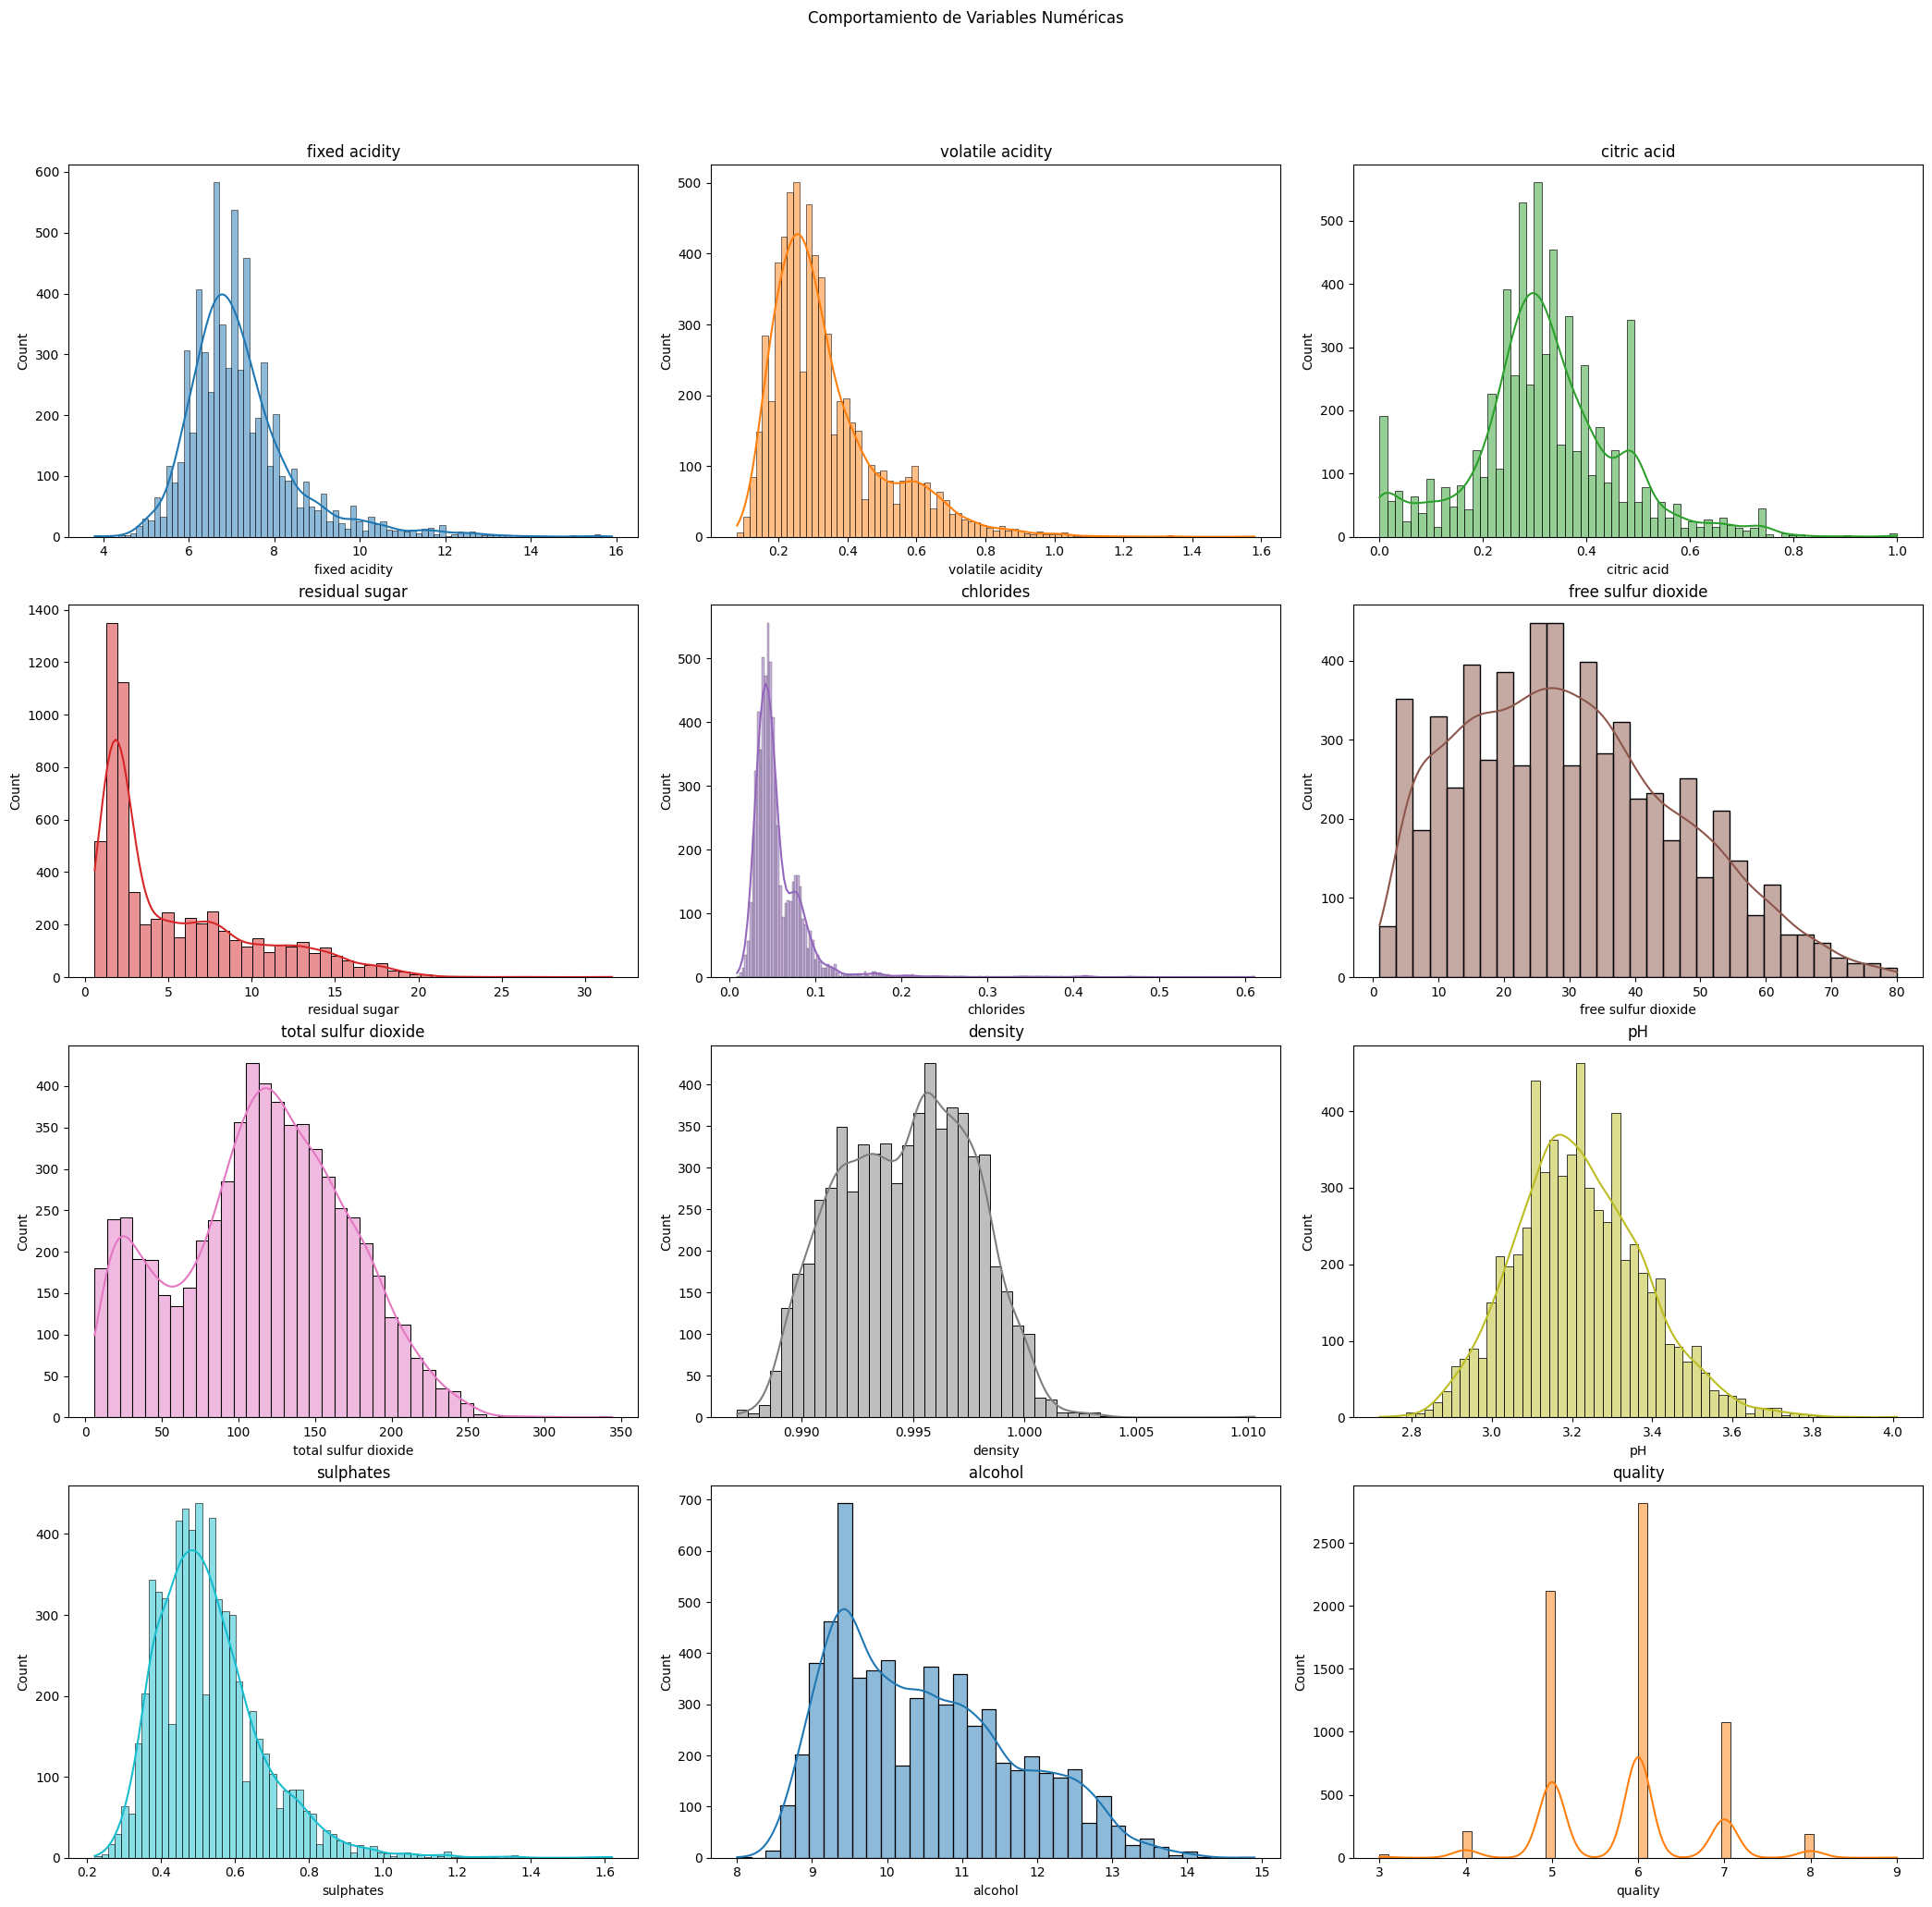

In [8]:
#Gráficos de Histogramas de frecuencia luego de la eliminación de atípicos
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data_mod.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data = data_mod, x = col, kde = True,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

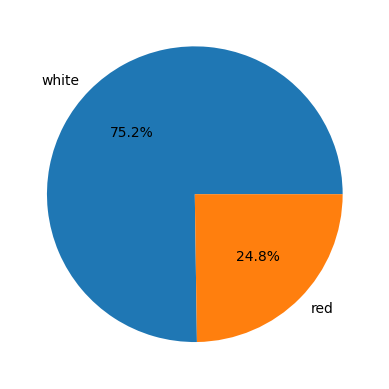

In [9]:
#Gáfico de Torta para la variable objetivo
plt.pie(x = data_mod['type'].value_counts(), labels = data_mod['type'].value_counts().index, autopct = '%0.1f%%')
plt.show()

In [10]:
#BALANCEO
data_red = data_mod[data_mod['type'] == 'red']
data_white = data_mod[data_mod['type'] == 'white']
print(f'El tamaño de la clase red es: {data_red.shape}\n El tamaño de la clase white es: {data_white.shape}')

El tamaño de la clase red es: (1595, 13)
 El tamaño de la clase white es: (4844, 13)


In [11]:
data_red_re = data_red.sample(data_white.shape[0], replace=True)
data_balanced = pd.concat([data_white, data_red_re])
data_balanced.reset_index(drop = True, inplace=True)
data_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9688 entries, 0 to 9687
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         9688 non-null   float64
 1   volatile acidity      9688 non-null   float64
 2   citric acid           9688 non-null   float64
 3   residual sugar        9688 non-null   float64
 4   chlorides             9688 non-null   float64
 5   free sulfur dioxide   9688 non-null   float64
 6   total sulfur dioxide  9688 non-null   float64
 7   density               9688 non-null   float64
 8   pH                    9688 non-null   float64
 9   sulphates             9688 non-null   float64
 10  alcohol               9688 non-null   float64
 11  quality               9688 non-null   int64  
 12  type                  9688 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 984.1+ KB


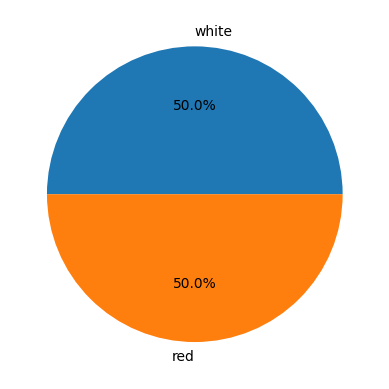

In [12]:
plt.pie(x = data_balanced['type'].value_counts(), labels = data_balanced['type'].value_counts().index, autopct = '%0.1f%%')
plt.show()

In [13]:
data_X = data_balanced.drop(columns='type')
data_y = data_balanced[['type']]

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = data_X.select_dtypes(include= ['int64','float64']).columns.to_list()
num_transformer1 = Pipeline(steps=[('scaler', MinMaxScaler())])
preprocessor1 = ColumnTransformer(transformers=[('num', num_transformer1, num_cols)], remainder='passthrough')
preprocessor1

,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [15]:
data_X_pre1 = preprocessor1.fit_transform(data_X)
data_X_pro1 = pd.DataFrame(data_X_pre1, columns= num_cols)
data_X_pro1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.264463,0.126667,0.36,0.648387,0.059801,0.556962,0.485207,0.598965,0.217054,0.164286,0.115942,0.500000
1,0.206612,0.146667,0.34,0.032258,0.066445,0.164557,0.372781,0.297111,0.449612,0.192857,0.217391,0.500000
2,0.355372,0.133333,0.40,0.203226,0.068106,0.367089,0.269231,0.344545,0.418605,0.157143,0.304348,0.500000
3,0.280992,0.100000,0.32,0.254839,0.081395,0.582278,0.532544,0.366106,0.364341,0.128571,0.275362,0.500000
4,0.280992,0.100000,0.32,0.254839,0.081395,0.582278,0.532544,0.366106,0.364341,0.128571,0.275362,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...
9683,0.231405,0.516667,0.02,0.058065,0.088040,0.177215,0.050296,0.394998,0.635659,0.271429,0.434783,0.500000
9684,0.297521,0.180000,0.33,0.058065,0.098007,0.101266,0.059172,0.327296,0.496124,0.271429,0.565217,0.500000
9685,0.239669,0.253333,0.24,0.035484,0.112957,0.215190,0.082840,0.331608,0.519380,0.271429,0.376812,0.500000
9686,0.669421,0.333333,0.66,0.061290,0.104651,0.063291,0.091716,0.521345,0.255814,0.242857,0.289855,0.333333


In [16]:
num_transformer2 = Pipeline(steps=[('scaler', StandardScaler())])
preprocessor2 = ColumnTransformer(transformers=[('num', num_transformer2, num_cols)], remainder='passthrough')
preprocessor2

,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [17]:
data_X_pre2 = preprocessor2.fit_transform(data_X)
data_X_pro2 = pd.DataFrame(data_X_pre2, columns= num_cols)
data_X_pro2

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.377797,-0.692502,0.347619,3.920805,-0.522752,1.218888,1.319711,2.001853,-1.531813,-0.762624,-1.446537,0.274902
1,-0.831617,-0.534305,0.225750,-0.689182,-0.425021,-0.694183,0.678346,-0.488767,0.307927,-0.515523,-0.842452,0.274902
2,0.335350,-0.639770,0.591358,0.590029,-0.400588,0.293208,0.087615,-0.097384,0.062629,-0.824399,-0.324665,0.274902
3,-0.248134,-0.903432,0.103881,0.976206,-0.205126,1.342312,1.589760,0.080517,-0.366644,-1.071499,-0.497261,0.274902
4,-0.248134,-0.903432,0.103881,0.976206,-0.205126,1.342312,1.589760,0.080517,-0.366644,-1.071499,-0.497261,0.274902
...,...,...,...,...,...,...,...,...,...,...,...,...
9683,-0.637123,2.392344,-1.724158,-0.496093,-0.107395,-0.632471,-1.161359,0.318905,1.779720,0.164002,0.452016,0.274902
9684,-0.118471,-0.270643,0.164815,-0.496093,0.039201,-1.002743,-1.110725,-0.239705,0.675876,0.164002,1.228697,0.274902
9685,-0.572291,0.309414,-0.383596,-0.665046,0.259096,-0.447335,-0.975701,-0.204125,0.859850,0.164002,0.106824,0.274902
9686,2.798946,0.942203,2.175658,-0.471957,0.136932,-1.187879,-0.925067,1.361408,-1.225190,-0.083098,-0.410963,-0.884040


In [18]:
import sklearn
from sklearn.preprocessing import OrdinalEncoder
categorical_cols = data_y.select_dtypes(include= 'object').columns
categorical_transformer = sklearn.compose.make_column_transformer((OrdinalEncoder(), categorical_cols),
                                                                 remainder = 'passthrough')
categorical_transformer

,transformers,"[('ordinalencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [19]:
data_transformed = pd.DataFrame(categorical_transformer.fit_transform(data_y),
                                columns=categorical_transformer.get_feature_names_out(),
                                index=data_y.index).rename(columns= lambda x: x.removeprefix('ordinalencoder__')).rename(columns= lambda x: x.removeprefix('remainder__'))
data_transformed

,type
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
9683,0.0
9684,0.0
9685,0.0
9686,0.0


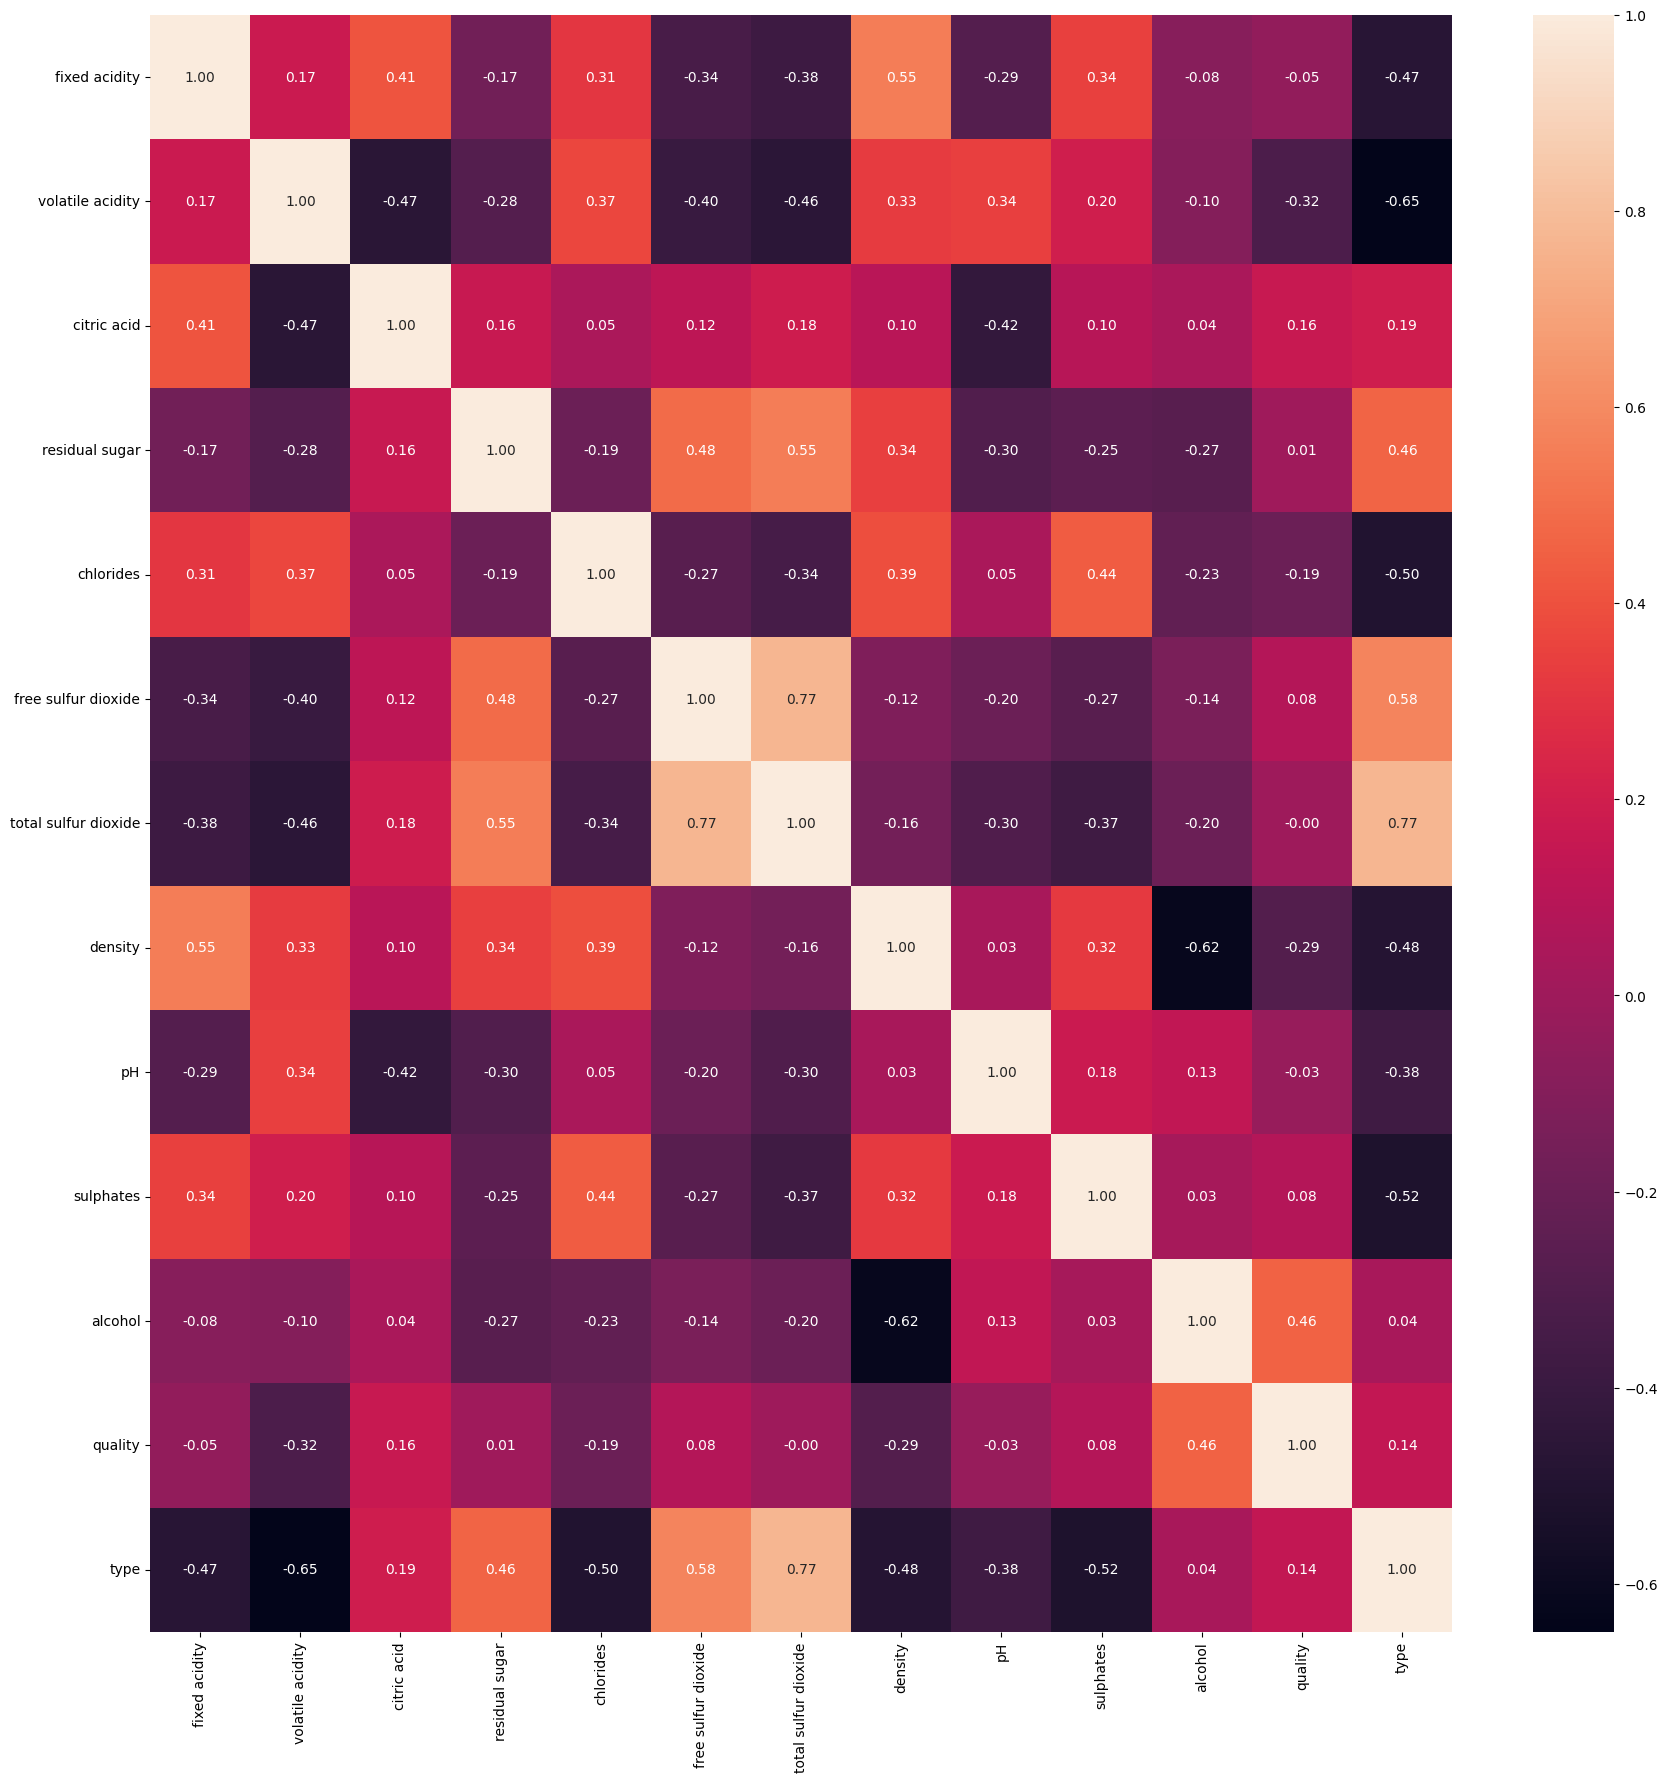

In [20]:
prueba = pd.concat([data_X_pro2, data_transformed], axis=1)

plt.figure(figsize= (21,21))
sns.heatmap(data=prueba.corr(numeric_only= True), annot= True, fmt= '0.2f')
plt.show()

## Prueba con modelo base para seleccionar estandarizacion o normalizacion

In [91]:
from sklearn.model_selection import train_test_split
X_trainN, X_testN, y_trainN, y_testN = train_test_split(data_X_pro1, data_y, train_size=0.7, random_state=32)
X_trainE, X_testE, y_trainE, y_testE = train_test_split(data_X_pro2, data_y, train_size=0.7, random_state=32)
print(f'El tamaño del conjunto de entrenamiento normalizado es: {X_trainN.shape} {y_trainN.shape}\ny el tamaño del conjunto de validacion normalizado es {X_testN.shape, y_testN.shape}')
print(f'El tamaño del conjunto de entrenamiento estandarizado es: {X_trainE.shape} {y_trainE.shape}\ny el tamaño del conjunto de validacion estandarizado es {X_testE.shape, y_testE.shape}')

El tamaño del conjunto de entrenamiento normalizado es: (6781, 12) (6781, 1)
y el tamaño del conjunto de validacion normalizado es ((2907, 12), (2907, 1))
El tamaño del conjunto de entrenamiento estandarizado es: (6781, 12) (6781, 1)
y el tamaño del conjunto de validacion estandarizado es ((2907, 12), (2907, 1))


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
modelN1 = DecisionTreeClassifier(random_state=32)
modelN2 = KNeighborsClassifier()
modelE1 = DecisionTreeClassifier(random_state=32)
modelE2 = KNeighborsClassifier()
modelN1.fit(X_trainN, y_trainN)
modelN2.fit(X_trainN, y_trainN)
modelE1.fit(X_trainE, y_trainE)
modelE2.fit(X_trainE, y_trainE)
pred1N = modelN1.predict(X_testN)
pred2N = modelN2.predict(X_testN)
pred1E = modelE1.predict(X_testE)
pred2E = modelE2.predict(X_testE)

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_testN, pred1N))
print(classification_report(y_testE, pred1E))

              precision    recall  f1-score   support

         red       0.98      1.00      0.99      1513
       white       1.00      0.98      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907

              precision    recall  f1-score   support

         red       0.98      1.00      0.99      1513
       white       0.99      0.98      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907



In [26]:
print(classification_report(y_testN, pred2N))
print(classification_report(y_testE, pred2E))

              precision    recall  f1-score   support

         red       0.99      1.00      0.99      1513
       white       1.00      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907

              precision    recall  f1-score   support

         red       0.99      1.00      0.99      1513
       white       1.00      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907



In [27]:
print("Train scores:")
print(f"DecisionTree Norm: {modelN1.score(X_trainN, y_trainN):.4f}")
print(f"DecisionTree Est:  {modelE1.score(X_trainE, y_trainE):.4f}")

print("\nTest scores:")
print(f"DecisionTree Norm: {modelN1.score(X_testN, y_testN):.4f}")
print(f"DecisionTree Est:  {modelE1.score(X_testE, y_testE):.4f}")

Train scores:
DecisionTree Norm: 0.9997
DecisionTree Est:  0.9997

Test scores:
DecisionTree Norm: 0.9890
DecisionTree Est:  0.9886


Se decidió usar el MinMaxScaler() LOS QUE TIENEN N

## Ajuste de Hiperparametros para los 10 modelos a probar
- Naive Bayes
- Regresión Logística
- K vecinos Más Cercanos
- Máquina de Soporte Vectorial
- Árbol de Decisión
- Extra Tree Classifier
- Random Forest
- Adaptative Boosting
- Gradient Boosting 
- Red Neuronal Artificial

In [28]:
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

In [29]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
model_1 = GaussianNB()
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf1 = GridSearchCV(estimator=model_1,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf1.fit(X_trainN, y_trainN)

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,GaussianNB()
,param_grid,{'var_smoothing': array([1.0000...00000000e-09])}
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [30]:
cv_results = pd.DataFrame(clf1.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_var_smoothing,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
17,0.052847,0.015769,0.191661,0.069912,0.028480,{'var_smoothing': 0.02848035868435802},0.971997,0.971239,0.982301,0.973451,...,0.004037,1,0.971986,0.971228,0.982294,0.973446,0.976400,0.975071,0.004022,1
9,0.047571,0.026544,0.243132,0.136622,0.151991,{'var_smoothing': 0.15199110829529336},0.971997,0.974926,0.981563,0.972714,...,0.003398,2,0.971984,0.974912,0.981556,0.972706,0.974186,0.975069,0.003405,2
18,0.032777,0.012501,0.153306,0.081292,0.023101,{'var_smoothing': 0.02310129700083159},0.971260,0.970501,0.983038,0.973451,...,0.004566,3,0.971248,0.970491,0.983033,0.973446,0.976400,0.974923,0.004545,3
12,0.042373,0.012750,0.225994,0.057809,0.081113,{'var_smoothing': 0.08111308307896872},0.971260,0.974926,0.983038,0.971976,...,0.004221,5,0.971250,0.974912,0.983032,0.971970,0.973449,0.974923,0.004246,4
14,0.051387,0.024955,0.203173,0.080506,0.053367,{'var_smoothing': 0.0533669923120631},0.971260,0.974189,0.983038,0.971976,...,0.004211,4,0.971248,0.974175,0.983032,0.971969,0.974188,0.974922,0.004221,5
11,0.041258,0.022905,0.125171,0.020330,0.100000,{'var_smoothing': 0.1},0.971997,0.974926,0.981563,0.972714,...,0.003439,6,0.971984,0.974912,0.981556,0.972707,0.973448,0.974922,0.003456,6
10,0.031326,0.006274,0.133619,0.019146,0.123285,{'var_smoothing': 0.12328467394420659},0.971260,0.974926,0.981563,0.972714,...,0.003541,7,0.971248,0.974912,0.981556,0.972706,0.974186,0.974922,0.003549,7
19,0.047455,0.026782,0.185686,0.088200,0.018738,{'var_smoothing': 0.01873817422860384},0.971997,0.969764,0.981563,0.973451,...,0.004194,8,0.971988,0.969752,0.981558,0.973446,0.977138,0.974776,0.004156,8
13,0.026224,0.002191,0.123334,0.028808,0.065793,{'var_smoothing': 0.0657933224657568},0.971260,0.973451,0.983038,0.973451,...,0.004188,9,0.971248,0.973437,0.983032,0.973446,0.972712,0.974775,0.004205,9
16,0.024095,0.001455,0.114255,0.004670,0.035112,{'var_smoothing': 0.03511191734215131},0.971997,0.971239,0.983038,0.971976,...,0.004384,10,0.971986,0.971228,0.983032,0.971970,0.974925,0.974628,0.004389,10


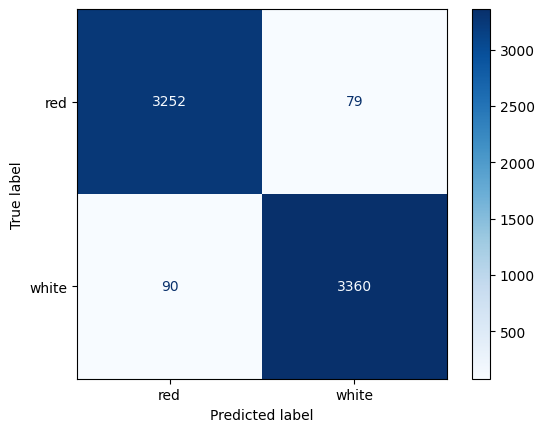

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict
labels = data['type'].unique()

best_clf1 = clf1.best_estimator_
y_train_pred = cross_val_predict(best_clf1, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val = confusion_matrix(y_trainN, y_train_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels).plot(cmap=plt.cm.Blues)

In [32]:
#Regresión Logística
from sklearn.linear_model import LogisticRegression
model_2 = LogisticRegression(solver= 'saga', random_state=32)
param_grid = {
    'penalty':['l1','l2','elasticnet'],
    'C':[0.001, 0.01, 0.1,1,10,100,1000]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf2 = GridSearchCV(estimator=model_2,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf2.fit(X_trainN, y_trainN)

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
35 fits failed out of a total of 105.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-pac

,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [33]:
cv_results2 = pd.DataFrame(clf2.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results2.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_penalty,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
9,0.659584,0.183767,0.230694,0.063196,1.0,l1,"{'C': 1, 'penalty': 'l1'}",0.993368,0.988938,0.991888,...,0.002652,1,0.993364,0.988932,0.991886,0.991885,0.997049,0.992623,0.002640,1
15,0.633827,0.185122,0.149770,0.063001,100.0,l1,"{'C': 100, 'penalty': 'l1'}",0.993368,0.987463,0.992625,...,0.003206,2,0.993364,0.987457,0.992623,0.990409,0.997049,0.992180,0.003186,2
18,0.623042,0.166781,0.125547,0.027067,1000.0,l1,"{'C': 1000, 'penalty': 'l1'}",0.993368,0.987463,0.992625,...,0.003206,2,0.993364,0.987457,0.992623,0.990409,0.997049,0.992180,0.003186,2
19,0.452760,0.109857,0.115906,0.023039,1000.0,l2,"{'C': 1000, 'penalty': 'l2'}",0.993368,0.987463,0.992625,...,0.003206,2,0.993364,0.987457,0.992623,0.990409,0.997049,0.992180,0.003186,2
13,0.395333,0.141858,0.159512,0.060229,10.0,l2,"{'C': 10, 'penalty': 'l2'}",0.993368,0.988938,0.991150,...,0.002271,5,0.993364,0.988932,0.991149,0.991147,0.995574,0.992033,0.002258,5
16,0.522625,0.175189,0.138567,0.037102,100.0,l2,"{'C': 100, 'penalty': 'l2'}",0.993368,0.988201,0.992625,...,0.002873,6,0.993364,0.988195,0.992623,0.989671,0.996311,0.992033,0.002854,6
12,0.593319,0.183146,0.111260,0.007462,10.0,l1,"{'C': 10, 'penalty': 'l1'}",0.993368,0.987463,0.992625,...,0.002991,7,0.993364,0.987457,0.992623,0.990409,0.996311,0.992033,0.002967,7
10,0.124027,0.029259,0.157639,0.064500,1.0,l2,"{'C': 1, 'penalty': 'l2'}",0.990420,0.985251,0.991888,...,0.003407,8,0.990415,0.985244,0.991886,0.988934,0.995574,0.990411,0.003397,8
6,0.160497,0.049433,0.244730,0.139379,0.1,l1,"{'C': 0.1, 'penalty': 'l1'}",0.983788,0.983038,0.987463,...,0.002174,9,0.983779,0.983028,0.987460,0.983772,0.988197,0.985247,0.002138,9
7,0.153366,0.086306,0.188814,0.084343,0.1,l2,"{'C': 0.1, 'penalty': 'l2'}",0.984525,0.979351,0.985988,...,0.002313,10,0.984519,0.979340,0.985986,0.983772,0.982296,0.983183,0.002260,10


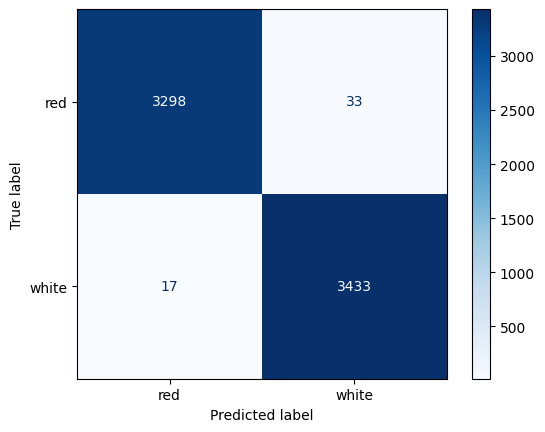

In [34]:
best_clf2 = clf2.best_estimator_
y_train_pred2 = cross_val_predict(best_clf2, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val2 = confusion_matrix(y_trainN, y_train_pred2)
ConfusionMatrixDisplay(confusion_matrix=cm_val2, display_labels=labels).plot(cmap=plt.cm.Blues)

In [35]:
#k vecinos mas cercanos
from sklearn.neighbors import KNeighborsClassifier
model_3 = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3,5,7,9,11,15,101],
    'p':[1,2]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf3 = GridSearchCV(estimator=model_3,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf3.fit(X_trainN, y_trainN)

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2]}"
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [36]:
cv_results3 = pd.DataFrame(clf3.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results3.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_p,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
0,0.063135,0.014928,1.081017,0.267692,3,1,"{'n_neighbors': 3, 'p': 1}",0.994842,0.993363,0.994100,...,0.002648,1,0.994841,0.993361,0.994099,0.987461,0.991149,0.992182,0.002664,1
4,0.063937,0.027513,0.858768,0.275674,7,1,"{'n_neighbors': 7, 'p': 1}",0.992631,0.989676,0.992625,...,0.001659,2,0.992629,0.989672,0.992624,0.988935,0.992624,0.991297,0.001644,2
2,0.049745,0.009039,0.654644,0.045104,5,1,"{'n_neighbors': 5, 'p': 1}",0.992631,0.989676,0.993363,...,0.002361,3,0.992629,0.989671,0.993361,0.986723,0.991149,0.990707,0.002361,3
8,0.045885,0.008286,0.878363,0.241053,11,1,"{'n_neighbors': 11, 'p': 1}",0.990420,0.986726,0.993363,...,0.002333,4,0.990417,0.986721,0.993361,0.988197,0.991149,0.989969,0.002315,4
6,0.054376,0.020888,0.932724,0.345496,9,1,"{'n_neighbors': 9, 'p': 1}",0.991157,0.987463,0.991888,...,0.002080,5,0.991154,0.987458,0.991886,0.987460,0.991886,0.989969,0.002067,5
1,0.052490,0.014495,0.622493,0.203749,3,2,"{'n_neighbors': 3, 'p': 2}",0.991157,0.989676,0.992625,...,0.002522,6,0.991156,0.989674,0.992624,0.986724,0.985987,0.989233,0.002539,6
10,0.051945,0.018187,0.777841,0.228501,15,1,"{'n_neighbors': 15, 'p': 1}",0.990420,0.985988,0.992625,...,0.002301,7,0.990417,0.985983,0.992623,0.987460,0.988936,0.989084,0.002306,7
3,0.069444,0.014161,0.746028,0.146843,5,2,"{'n_neighbors': 5, 'p': 2}",0.991157,0.988938,0.990413,...,0.002411,8,0.991155,0.988934,0.990412,0.984511,0.986725,0.988347,0.002443,8
5,0.052217,0.012837,0.622945,0.156475,7,2,"{'n_neighbors': 7, 'p': 2}",0.990420,0.988938,0.989676,...,0.002302,9,0.990418,0.988934,0.989674,0.983774,0.988199,0.988200,0.002333,9
9,0.053631,0.021581,0.700212,0.150835,11,2,"{'n_neighbors': 11, 'p': 2}",0.988946,0.985251,0.990413,...,0.001853,10,0.988943,0.985245,0.990411,0.986722,0.986724,0.987609,0.001832,10


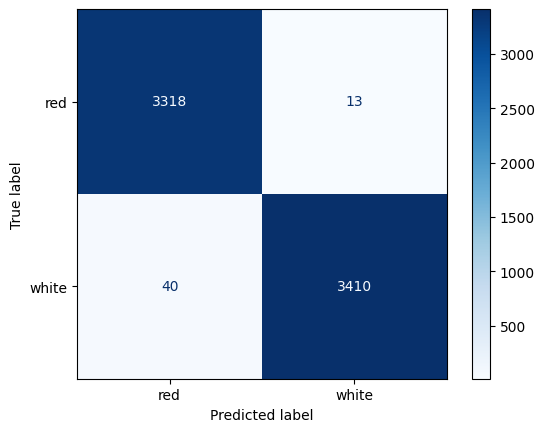

In [37]:
best_clf3 = clf3.best_estimator_
y_train_pred3 = cross_val_predict(best_clf3, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val3 = confusion_matrix(y_trainN, y_train_pred3)
ConfusionMatrixDisplay(confusion_matrix=cm_val3, display_labels=labels).plot(cmap=plt.cm.Blues)

In [38]:
#Maquina de soporte vectorial
from sklearn.svm import SVC
model_4 = SVC(random_state=32)
param_grid = {
    'C': [0.001, 0.01, 0.1, 10, 100],
    'kernel': ['poly', 'linear', 'rbf', 'sigmoid'],
    'degree': [2,3]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf4 = GridSearchCV(estimator=model_4,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf4.fit(X_trainN, y_trainN)

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,SVC(random_state=32)
,param_grid,"{'C': [0.001, 0.01, ...], 'degree': [2, 3], 'kernel': ['poly', 'linear', ...]}"
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [39]:
cv_results4 = pd.DataFrame(clf4.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results4.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_degree,param_kernel,params,split0_test_accuracy,split1_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
30,0.348188,0.125433,0.255137,0.068385,10.0,3,rbf,"{'C': 10, 'degree': 3, 'kernel': 'rbf'}",0.997789,0.993363,...,0.002140,1,0.997788,0.993361,0.998525,0.994098,0.997787,0.996312,0.002138,1
26,0.434753,0.125792,0.386217,0.147987,10.0,2,rbf,"{'C': 10, 'degree': 2, 'kernel': 'rbf'}",0.997789,0.993363,...,0.002140,1,0.997788,0.993361,0.998525,0.994098,0.997787,0.996312,0.002138,1
28,0.586544,0.302557,0.164655,0.035107,10.0,3,poly,"{'C': 10, 'degree': 3, 'kernel': 'poly'}",0.998526,0.992625,...,0.001999,3,0.998526,0.992623,0.997049,0.994836,0.996312,0.995869,0.002012,3
38,0.355736,0.090975,0.246230,0.069966,100.0,3,rbf,"{'C': 100, 'degree': 3, 'kernel': 'rbf'}",0.995578,0.993363,...,0.001405,4,0.995577,0.993361,0.997049,0.994836,0.997050,0.995575,0.001400,4
34,0.359032,0.124729,0.235019,0.064308,100.0,2,rbf,"{'C': 100, 'degree': 2, 'kernel': 'rbf'}",0.995578,0.993363,...,0.001405,4,0.995577,0.993361,0.997049,0.994836,0.997050,0.995575,0.001400,4
36,1.115041,0.210936,0.133139,0.021328,100.0,3,poly,"{'C': 100, 'degree': 3, 'kernel': 'poly'}",0.996315,0.992625,...,0.001493,6,0.996314,0.992624,0.997049,0.994836,0.994837,0.995132,0.001519,6
24,0.422965,0.143825,0.189417,0.060748,10.0,2,poly,"{'C': 10, 'degree': 2, 'kernel': 'poly'}",0.994842,0.991888,...,0.002073,7,0.994839,0.991885,0.994836,0.992623,0.997787,0.994394,0.002066,7
32,0.785431,0.185105,0.160625,0.037234,100.0,2,poly,"{'C': 100, 'degree': 2, 'kernel': 'poly'}",0.995578,0.990413,...,0.002196,8,0.995577,0.990411,0.995573,0.991886,0.995574,0.993804,0.002218,8
20,0.434105,0.141705,0.321216,0.100148,0.1,3,poly,"{'C': 0.1, 'degree': 3, 'kernel': 'poly'}",0.994842,0.989676,...,0.002748,9,0.994839,0.989670,0.991885,0.993360,0.997787,0.993508,0.002737,9
16,0.444366,0.116437,0.304593,0.071164,0.1,2,poly,"{'C': 0.1, 'degree': 2, 'kernel': 'poly'}",0.993368,0.989676,...,0.002456,10,0.993364,0.989670,0.991886,0.991885,0.997049,0.992771,0.002443,10


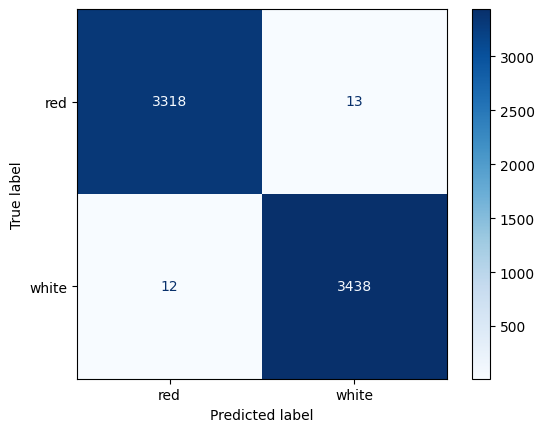

In [40]:
best_clf4 = clf4.best_estimator_
y_train_pred4 = cross_val_predict(best_clf4, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val4 = confusion_matrix(y_trainN, y_train_pred4)
ConfusionMatrixDisplay(confusion_matrix=cm_val4, display_labels=labels).plot(cmap=plt.cm.Blues)

Profundidad del árbol: 16
Número de hojas: 63


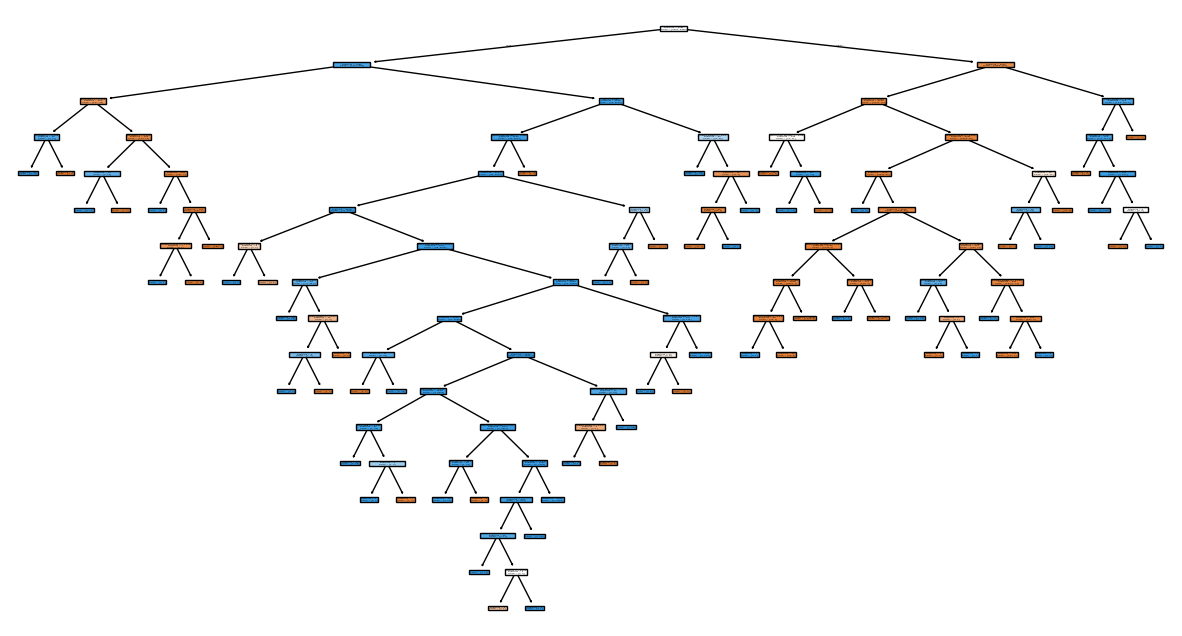

In [41]:
#Árbol de decisión
from sklearn.tree import DecisionTreeClassifier, plot_tree
model_tree = DecisionTreeClassifier(random_state=32)
model_tree.fit(X_trainN, y_trainN)
print(f'Profundidad del árbol: {model_tree.get_depth()}\nNúmero de hojas: {model_tree.get_n_leaves()}')
fig, ax = plt.subplots(figsize=(15,8))
plot = plot_tree(decision_tree= model_tree, feature_names=num_cols, filled=True, impurity=False, ax=ax)

In [42]:
#Árbol de decisión
model_5 = DecisionTreeClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None, 5,10,20,30,50,60],
    'min_samples_split': [2,4,6]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf5 = GridSearchCV(estimator=model_5,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf5.fit(X_trainN, y_trainN)

,estimator,DecisionTreeC...ndom_state=32)
,param_grid,"{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [43]:
cv_results5 = pd.DataFrame(clf5.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results5.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,params,split0_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
313,0.113148,0.024075,0.156446,0.040793,log_loss,14,60,4,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",0.994842,...,0.000588,1,0.994840,0.994837,0.994837,0.994837,0.993362,0.994542,0.000590,1
103,0.094649,0.039370,0.157266,0.058321,entropy,14,60,4,"{'criterion': 'entropy', 'max_depth': 14, 'max...",0.994842,...,0.000588,1,0.994840,0.994837,0.994837,0.994837,0.993362,0.994542,0.000590,1
100,0.093319,0.030503,0.136780,0.033348,entropy,14,50,4,"{'criterion': 'entropy', 'max_depth': 14, 'max...",0.994105,...,0.000870,5,0.994103,0.994837,0.994837,0.994837,0.992624,0.994247,0.000860,3
310,0.098054,0.040611,0.159654,0.053985,log_loss,14,50,4,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",0.994105,...,0.000870,5,0.994103,0.994837,0.994837,0.994837,0.992624,0.994247,0.000860,3
312,0.076014,0.011179,0.112288,0.004767,log_loss,14,60,2,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",0.994842,...,0.000713,3,0.994840,0.994837,0.993362,0.994837,0.993362,0.994247,0.000723,5
102,0.083751,0.030347,0.167462,0.046127,entropy,14,60,2,"{'criterion': 'entropy', 'max_depth': 14, 'max...",0.994842,...,0.000713,3,0.994840,0.994837,0.993362,0.994837,0.993362,0.994247,0.000723,5
294,0.097942,0.039001,0.126837,0.035914,log_loss,14,None,2,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",0.993368,...,0.000490,7,0.993366,0.994099,0.994099,0.994837,0.994099,0.994100,0.000465,7
84,0.102567,0.019014,0.164367,0.047988,entropy,14,None,2,"{'criterion': 'entropy', 'max_depth': 14, 'max...",0.993368,...,0.000490,7,0.993366,0.994099,0.994099,0.994837,0.994099,0.994100,0.000465,7
99,0.100603,0.022813,0.150305,0.038076,entropy,14,50,2,"{'criterion': 'entropy', 'max_depth': 14, 'max...",0.994105,...,0.000865,9,0.994103,0.994837,0.993362,0.994837,0.992624,0.993952,0.000860,9
309,0.091957,0.037681,0.150804,0.053624,log_loss,14,50,2,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",0.994105,...,0.000865,9,0.994103,0.994837,0.993362,0.994837,0.992624,0.993952,0.000860,9


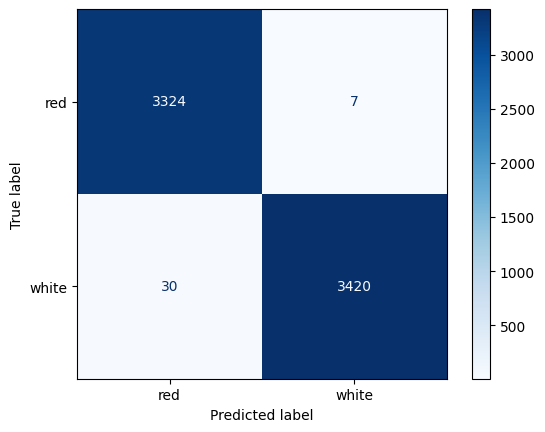

In [44]:
best_clf5 = clf5.best_estimator_
y_train_pred5 = cross_val_predict(best_clf5, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val5 = confusion_matrix(y_trainN, y_train_pred5)
ConfusionMatrixDisplay(confusion_matrix=cm_val5, display_labels=labels).plot(cmap=plt.cm.Blues)

In [45]:
#Extra Tree Classifier
from sklearn.ensemble import ExtraTreesClassifier
model_6 = ExtraTreesClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None,5,10,20,30,50,60],
    'min_samples_split': [2,4,6],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf6 = GridSearchCV(estimator=model_6,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf6.fit(X_trainN, y_trainN)

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,ExtraTreesCla...ndom_state=32)
,param_grid,"{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...], ...}"
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [46]:
cv_results6 = pd.DataFrame(clf6.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results6.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,param_n_estimators,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
757,2.550511,0.551650,0.275636,0.078305,gini,14,None,2,200,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.001285,1,0.998526,0.998525,0.998525,0.995574,0.999262,0.998082,0.001286,1
759,5.208378,0.533409,0.499461,0.122282,gini,14,None,2,500,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.001285,1,0.998526,0.998525,0.998525,0.995574,0.999262,0.998082,0.001286,1
758,5.057540,0.900648,0.444276,0.133277,gini,14,None,2,400,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.001285,1,0.998526,0.998525,0.998525,0.995574,0.999262,0.998082,0.001286,1
337,2.755668,0.602845,0.338527,0.130121,entropy,14,None,2,200,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001238,5,0.997788,0.997787,0.998525,0.995574,0.999262,0.997787,0.001234,4
1177,2.334143,0.464278,0.309578,0.071941,log_loss,14,None,2,200,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001238,5,0.997788,0.997787,0.998525,0.995574,0.999262,0.997787,0.001234,4
338,5.132869,0.310777,0.438674,0.124727,entropy,14,None,2,400,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001054,9,0.997788,0.998525,0.997049,0.996311,0.999262,0.997787,0.001043,6
1178,4.714115,0.519588,0.488239,0.130278,log_loss,14,None,2,400,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001054,9,0.997788,0.998525,0.997049,0.996311,0.999262,0.997787,0.001043,6
756,1.518929,0.275659,0.277921,0.092033,gini,14,None,2,100,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.001143,4,0.998526,0.997787,0.998525,0.995574,0.998525,0.997787,0.001143,8
339,5.666224,1.056000,0.469776,0.139801,entropy,14,None,2,500,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001323,7,0.998526,0.998525,0.997049,0.995574,0.999262,0.997787,0.001320,9
1179,5.846576,0.319056,0.471334,0.146413,log_loss,14,None,2,500,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001323,7,0.998526,0.998525,0.997049,0.995574,0.999262,0.997787,0.001320,9


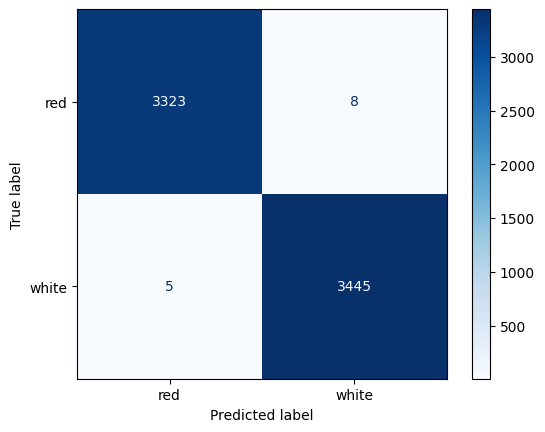

In [47]:
best_clf6 = clf6.best_estimator_
y_train_pred6 = cross_val_predict(best_clf6, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val6 = confusion_matrix(y_trainN, y_train_pred6)
ConfusionMatrixDisplay(confusion_matrix=cm_val6, display_labels=labels).plot(cmap=plt.cm.Blues)

In [48]:
#Random forest Classifier
from sklearn.ensemble import RandomForestClassifier
model_7 = RandomForestClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None,5,10,20,30,50,60],
    'min_samples_split': [2,4,6],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf7 = GridSearchCV(estimator=model_7,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf7.fit(X_trainN, y_trainN)

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestC...ndom_state=32)
,param_grid,"{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...], ...}"
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,400


In [49]:
cv_results7 = pd.DataFrame(clf7.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results7.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,param_n_estimators,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
1183,9.142874,0.690826,0.407171,0.102635,log_loss,14,None,4,500,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.000978,1,0.997789,0.997049,0.997787,0.996312,0.999262,0.99764,0.000979,1
255,10.404163,1.229681,0.461189,0.116693,entropy,10,None,2,500,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.000978,1,0.997789,0.997049,0.997787,0.996312,0.999262,0.99764,0.000979,1
1179,8.904850,1.474954,0.316737,0.081239,log_loss,14,None,2,500,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.000978,1,0.997789,0.997049,0.997787,0.996312,0.999262,0.99764,0.000979,1
1094,7.219530,1.022658,0.342849,0.085654,log_loss,10,None,2,400,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.000978,1,0.997789,0.997049,0.997787,0.996312,0.999262,0.99764,0.000979,1
1095,9.766932,1.660551,0.354973,0.099079,log_loss,10,None,2,500,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.000978,1,0.997789,0.997049,0.997787,0.996312,0.999262,0.99764,0.000979,1
759,9.445153,1.291123,0.310654,0.067223,gini,14,None,2,500,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.000978,1,0.997789,0.997049,0.997787,0.996312,0.999262,0.99764,0.000979,1
1182,8.331791,1.068054,0.281545,0.062187,log_loss,14,None,4,400,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.000978,1,0.997789,0.997049,0.997787,0.996312,0.999262,0.99764,0.000979,1
343,9.645641,1.919415,0.374075,0.115444,entropy,14,None,4,500,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.000978,1,0.997789,0.997049,0.997787,0.996312,0.999262,0.99764,0.000979,1
339,10.480640,0.378354,0.368977,0.101957,entropy,14,None,2,500,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.000978,1,0.997789,0.997049,0.997787,0.996312,0.999262,0.99764,0.000979,1
254,7.946042,0.859013,0.376527,0.106227,entropy,10,None,2,400,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.000978,1,0.997789,0.997049,0.997787,0.996312,0.999262,0.99764,0.000979,1


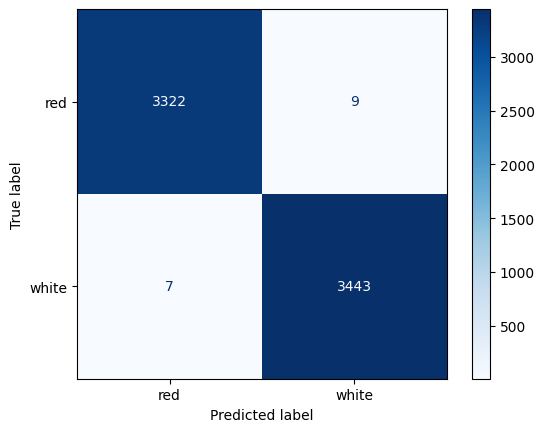

In [50]:
best_clf7 = clf7.best_estimator_
y_train_pred7 = cross_val_predict(best_clf7, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val7 = confusion_matrix(y_trainN, y_train_pred7)
ConfusionMatrixDisplay(confusion_matrix=cm_val7, display_labels=labels).plot(cmap=plt.cm.Blues)

In [51]:
#Adaptive boosting Classifier
from sklearn.ensemble import AdaBoostClassifier
model_8 = AdaBoostClassifier(random_state=32)
param_grid = {
    'learning_rate': [0.01, 0.1, 1,10,100],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf8 = GridSearchCV(estimator=model_8,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf8.fit(X_trainN, y_trainN)

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,AdaBoostClass...ndom_state=32)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [100, 200, ...]}"
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [52]:
cv_results8 = pd.DataFrame(clf8.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results8.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_n_estimators,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
11,15.250449,1.993960,0.779207,0.203261,1.00,500,"{'learning_rate': 1, 'n_estimators': 500}",0.995578,0.994838,0.992625,...,0.001786,1,0.995577,0.994837,0.992624,0.997049,0.997787,0.995575,0.001807,1
10,14.170055,2.258473,0.600218,0.184667,1.00,400,"{'learning_rate': 1, 'n_estimators': 400}",0.994842,0.992625,0.993363,...,0.002206,2,0.994840,0.992624,0.993361,0.997049,0.998525,0.995280,0.002218,2
9,5.499140,0.960307,0.356496,0.073862,1.00,200,"{'learning_rate': 1, 'n_estimators': 200}",0.993368,0.991150,0.990413,...,0.002130,3,0.993365,0.991149,0.990411,0.995574,0.995574,0.993215,0.002158,3
8,3.622485,0.676455,0.370719,0.029327,1.00,100,"{'learning_rate': 1, 'n_estimators': 100}",0.993368,0.991150,0.987463,...,0.002499,4,0.993365,0.991148,0.987462,0.990410,0.994836,0.991444,0.002538,4
7,14.210104,3.102616,0.638911,0.117946,0.10,500,"{'learning_rate': 0.1, 'n_estimators': 500}",0.989683,0.985988,0.988201,...,0.002451,5,0.989680,0.985983,0.988198,0.990410,0.993361,0.989526,0.002443,5
6,12.104063,1.858740,0.711954,0.201246,0.10,400,"{'learning_rate': 0.1, 'n_estimators': 400}",0.988946,0.985988,0.988201,...,0.001902,6,0.988943,0.985983,0.988198,0.988935,0.991886,0.988789,0.001890,6
5,5.354073,0.767675,0.426475,0.117713,0.10,200,"{'learning_rate': 0.1, 'n_estimators': 200}",0.986735,0.985251,0.985988,...,0.001779,7,0.986731,0.985244,0.985986,0.987460,0.990410,0.987166,0.001782,7
4,2.419472,0.187433,0.231134,0.065363,0.10,100,"{'learning_rate': 0.1, 'n_estimators': 100}",0.983788,0.983776,0.981563,...,0.002175,8,0.983783,0.983769,0.981562,0.983035,0.988197,0.984069,0.002217,8
3,15.087567,1.688268,0.709085,0.145440,0.01,500,"{'learning_rate': 0.01, 'n_estimators': 500}",0.977155,0.973451,0.974926,...,0.003546,9,0.977144,0.973438,0.974921,0.977131,0.983771,0.977281,0.003535,9
2,10.938212,1.543855,0.633054,0.193938,0.01,400,"{'learning_rate': 0.01, 'n_estimators': 400}",0.977892,0.969764,0.972714,...,0.004550,10,0.977879,0.969744,0.972707,0.976393,0.983032,0.975951,0.004541,10


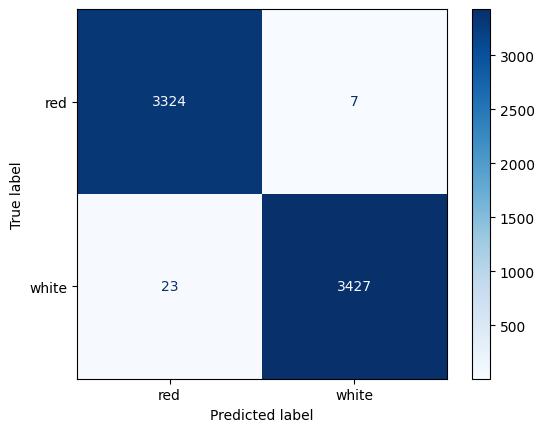

In [53]:
best_clf8 = clf8.best_estimator_
y_train_pred8 = cross_val_predict(best_clf8, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val8 = confusion_matrix(y_trainN, y_train_pred8)
ConfusionMatrixDisplay(confusion_matrix=cm_val8, display_labels=labels).plot(cmap=plt.cm.Blues)

In [54]:
#GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
model_9 = GradientBoostingClassifier(random_state=32)
param_grid = {
    'criterion': ['friedman_mse', 'squared_error'],
    'max_depth': [5,7,9,12],
    'max_leaf_nodes': [10,40,None],
    'min_samples_split': [2,3],
    'n_estimators': [100,200,300,400]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf9 = RandomizedSearchCV(estimator= model_9, param_distributions=param_grid, cv=cv, scoring=scoring,
                          refit='f1_macro',
                          n_jobs=-1, n_iter=96)
clf9.fit(X_trainN, y_trainN)

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,GradientBoost...ndom_state=32)
,param_distributions,"{'criterion': ['friedman_mse', 'squared_error'], 'max_depth': [5, 7, ...], 'max_leaf_nodes': [10, 40, ...], 'min_samples_split': [2, 3], ...}"
,n_iter,96
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [55]:
cv_results9 = pd.DataFrame(clf9.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results9.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_leaf_nodes,param_max_depth,param_criterion,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
26,25.702408,2.433100,0.178396,0.049058,400,2,40,12,squared_error,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.001178,1,0.997051,0.995574,0.997049,0.997049,0.999262,0.997197,0.001180,1
27,12.090811,0.803533,0.145284,0.036095,200,2,40,7,squared_error,"{'n_estimators': 200, 'min_samples_split': 2, ...",...,0.001265,1,0.997789,0.995574,0.997049,0.996312,0.999262,0.997197,0.001269,2
28,20.982846,3.225223,0.234503,0.059080,300,2,40,7,friedman_mse,"{'n_estimators': 300, 'min_samples_split': 2, ...",...,0.001265,1,0.997789,0.995574,0.997049,0.996312,0.999262,0.997197,0.001269,2
89,17.618264,2.295980,0.156733,0.039543,400,2,None,5,squared_error,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.001600,4,0.997789,0.994837,0.997787,0.995574,0.999262,0.997050,0.001616,4
78,13.013525,2.301849,0.137548,0.018319,300,2,None,5,squared_error,"{'n_estimators': 300, 'min_samples_split': 2, ...",...,0.001600,4,0.997789,0.994837,0.997787,0.995574,0.999262,0.997050,0.001616,4
9,25.827072,2.855422,0.190145,0.045076,400,3,None,7,squared_error,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.001392,4,0.997789,0.995574,0.997049,0.995574,0.999262,0.997050,0.001400,6
30,15.164082,1.950646,0.142869,0.032703,300,2,40,5,squared_error,"{'n_estimators': 300, 'min_samples_split': 2, ...",...,0.001392,4,0.997789,0.995574,0.997049,0.995574,0.999262,0.997050,0.001400,6
69,22.350635,1.963157,0.173772,0.036142,400,2,None,7,squared_error,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.001392,4,0.997789,0.995574,0.997049,0.995574,0.999262,0.997050,0.001400,6
19,21.320774,1.765135,0.155895,0.031843,300,2,40,12,friedman_mse,"{'n_estimators': 300, 'min_samples_split': 2, ...",...,0.001040,4,0.997789,0.995574,0.997049,0.996312,0.998525,0.997050,0.001043,9
70,16.644410,2.508389,0.155242,0.038349,400,2,10,5,squared_error,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.001422,10,0.996314,0.994837,0.997049,0.997049,0.999262,0.996902,0.001430,10


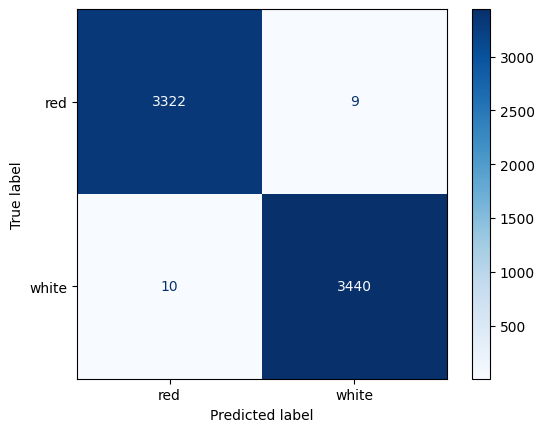

In [56]:
best_clf9 = clf9.best_estimator_
y_train_pred9 = cross_val_predict(best_clf9, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val9 = confusion_matrix(y_trainN, y_train_pred9)
ConfusionMatrixDisplay(confusion_matrix=cm_val9, display_labels=labels).plot(cmap=plt.cm.Blues)

In [57]:
#Red Neuronal Perceptrón Multicapa
from sklearn.neural_network import MLPClassifier
model_10 = MLPClassifier(random_state=32)
param_grid = {
    'hidden_layer_sizes': [(10,),(20,10,5),(20,10),(20,),(50,40,30,20,10)],
    'activation': ['relu','tanh','logistic'],
    'solver': ['adam','lbfgs','sgd'],
    'learning_rate_init': [0.01, 0.1, 1, 10, 100],
    'max_iter': [50,70,100,200]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf10 = RandomizedSearchCV(estimator= model_10, param_distributions=param_grid, cv=cv, scoring=scoring,
                           refit='f1_macro',
                          n_jobs=-1, n_iter=180)
clf10.fit(X_trainN, y_trainN)

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
2 fits failed out of a total of 900.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packa

,estimator,MLPClassifier(random_state=32)
,param_distributions,"{'activation': ['relu', 'tanh', ...], 'hidden_layer_sizes': [(10,), (20, ...), ...], 'learning_rate_init': [0.01, 0.1, ...], 'max_iter': [50, 70, ...], ...}"
,n_iter,180
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [58]:
cv_results10 = pd.DataFrame(clf10.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results10.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_solver,param_max_iter,param_learning_rate_init,param_hidden_layer_sizes,param_activation,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
92,3.564628,0.524598,0.181634,0.042467,lbfgs,200,1.00,"(20,)",tanh,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.002791,1,0.998526,0.994098,0.998525,0.991149,0.996312,0.995722,0.002815,1
34,2.814797,0.908294,0.265462,0.117143,lbfgs,100,10.00,"(20,)",tanh,"{'solver': 'lbfgs', 'max_iter': 100, 'learning...",...,0.002772,2,0.998526,0.994098,0.998525,0.991149,0.995574,0.995574,0.002799,2
28,2.550418,0.354034,0.146242,0.004938,lbfgs,100,0.10,"(20,)",tanh,"{'solver': 'lbfgs', 'max_iter': 100, 'learning...",...,0.002772,2,0.998526,0.994098,0.998525,0.991149,0.995574,0.995574,0.002799,2
2,2.825247,0.282070,0.199936,0.038280,lbfgs,200,0.01,"(20,)",relu,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.002683,4,0.997789,0.995574,0.997787,0.990411,0.995574,0.995427,0.002696,4
150,2.114054,0.595574,0.167041,0.037702,lbfgs,200,10.00,"(10,)",logistic,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.001449,9,0.994102,0.994098,0.996311,0.993361,0.997050,0.994984,0.001430,5
60,7.365681,2.194231,0.125225,0.005644,sgd,200,1.00,"(20,)",tanh,"{'solver': 'sgd', 'max_iter': 200, 'learning_r...",...,0.002585,10,0.993364,0.994836,0.997787,0.991148,0.997787,0.994984,0.002572,6
168,4.300946,0.505872,0.244863,0.067882,lbfgs,100,10.00,"(20, 10)",logistic,"{'solver': 'lbfgs', 'max_iter': 100, 'learning...",...,0.002547,8,0.996314,0.991147,0.995574,0.993361,0.998525,0.994984,0.002530,7
143,12.034235,1.690975,0.148765,0.026221,adam,70,0.01,"(50, 40, 30, 20, 10)",relu,"{'solver': 'adam', 'max_iter': 70, 'learning_r...",...,0.002932,7,0.997051,0.991148,0.996312,0.991885,0.998525,0.994984,0.002929,8
18,1.914711,0.475234,0.278850,0.151061,lbfgs,100,10.00,"(20,)",relu,"{'solver': 'lbfgs', 'max_iter': 100, 'learning...",...,0.002690,5,0.997788,0.992623,0.995574,0.991148,0.997787,0.994984,0.002697,9
20,1.615970,0.489671,0.224587,0.073480,lbfgs,100,0.01,"(20,)",relu,"{'solver': 'lbfgs', 'max_iter': 100, 'learning...",...,0.002690,5,0.997788,0.992623,0.995574,0.991148,0.997787,0.994984,0.002697,9


## Validación cruzada en un mismo for

In [58]:
hola = [[],[]]
hola[0].append(4)
hola[1].append(6)
print(hola)
print(hola[0])

[[4], [6]]
[4]


In [59]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score


strtfdKFold = StratifiedKFold(n_splits=10)
folds = list(strtfdKFold.split(X_trainN, y_trainN))

models = {
    'Naive Bayes': clf1.best_estimator_,
    'Regresión Logística': clf2.best_estimator_,
    'KNN': clf3.best_estimator_,
    'Maquina de Soporte Vectorial': clf4.best_estimator_,
    'Árbol de Decisión': clf5.best_estimator_,
    'Extra Trees': clf6.best_estimator_,
    'Random Forest': clf7.best_estimator_,
    'Adaptative Boosting': clf8.best_estimator_,
    'Gradient Boosting': clf9.best_estimator_,
    'Multi Layer Perceptron': clf10.best_estimator_
}

results = {name: {'accuracy': [], 'f1': [], 'recall': [], 'precision': [],
                  'y_test': [], 'y_pred': []}         
           for name in models}

for model_name, model in models.items():
    for train_index, test_index in folds:
        X_train_cv, X_test_cv = X_trainN.iloc[train_index], X_trainN.iloc[test_index]
        y_train_cv, y_test_cv = y_trainN.iloc[train_index], y_trainN.iloc[test_index]
        
        model.fit(X_train_cv, y_train_cv)
        pred = model.predict(X_test_cv)
        
        results[model_name]['y_test'].extend(y_test_cv['type'].tolist()) 
        results[model_name]['y_pred'].extend(pred)        
        results[model_name]['accuracy'].append(accuracy_score(y_test_cv, pred))
        results[model_name]['f1'].append(f1_score(y_test_cv, pred, average='macro'))
        results[model_name]['recall'].append(recall_score(y_test_cv, pred, average='macro'))
        results[model_name]['precision'].append(precision_score(y_test_cv, pred, average='macro'))

C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\olgam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the sha

In [73]:
for model in results:
    print(f"f1 de {model}: {np.mean(results[model]['f1'])*100}")

f1 de Naive Bayes: 97.52174506581213
f1 de Regresión Logística: 99.24752747436013
f1 de KNN: 99.24770275194916
f1 de Maquina de Soporte Vectorial: 99.61639971574752
f1 de Árbol de Decisión: 99.29196856500498
f1 de Extra Trees: 99.77873249763599
f1 de Random Forest: 99.76400002711702
f1 de Adaptative Boosting: 99.45426247169218
f1 de Gradient Boosting: 99.7344950835964
f1 de Multi Layer Perceptron: 99.57219409121743


In [74]:
for model in results:
    print(f"accuracy de {model}: {np.mean(results[model]['accuracy'])*100}")

accuracy de Naive Bayes: 97.52240628027508
accuracy de Regresión Logística: 99.24783105469173
accuracy de KNN: 99.24785277672787
accuracy de Maquina de Soporte Vectorial: 99.61654089607744
accuracy de Árbol de Decisión: 99.29212228637464
accuracy de Extra Trees: 99.77880450601917
accuracy de Random Forest: 99.76407696551843
accuracy de Adaptative Boosting: 99.45438589631638
accuracy de Gradient Boosting: 99.7345784404447
accuracy de Multi Layer Perceptron: 99.57231483050295


In [75]:
for model in results:
    print(f"precision de {model}: {np.mean(results[model]['precision'])*100}")

precision de Naive Bayes: 97.52311064552848
precision de Regresión Logística: 99.25335983175312
precision de KNN: 99.24555481946327
precision de Maquina de Soporte Vectorial: 99.62026700873396
precision de Árbol de Decisión: 99.28949219690722
precision de Extra Trees: 99.77994408809192
precision de Random Forest: 99.76510254446052
precision de Adaptative Boosting: 99.45209751074793
precision de Gradient Boosting: 99.73525171696897
precision de Multi Layer Perceptron: 99.5714636198921


In [76]:
for model in results:
    print(f"recall de {model}: {np.mean(results[model]['recall'])*100}")

recall de Naive Bayes: 97.52427342729347
recall de Regresión Logística: 99.24372484955667
recall de KNN: 99.2536028608666
recall de Maquina de Soporte Vectorial: 99.613832655879
recall de Árbol de Decisión: 99.29660381547912
recall de Extra Trees: 99.7779982533953
recall de Random Forest: 99.76350549977211
recall de Adaptative Boosting: 99.45811315090151
recall de Gradient Boosting: 99.73451999252573
recall de Multi Layer Perceptron: 99.5734879633604


Matriz de Naive Bayes


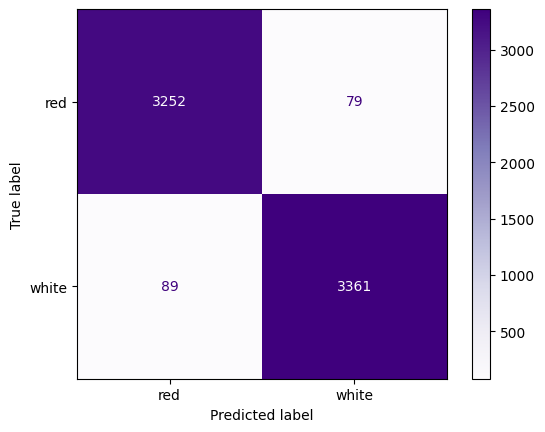

Matriz de Regresión Logística


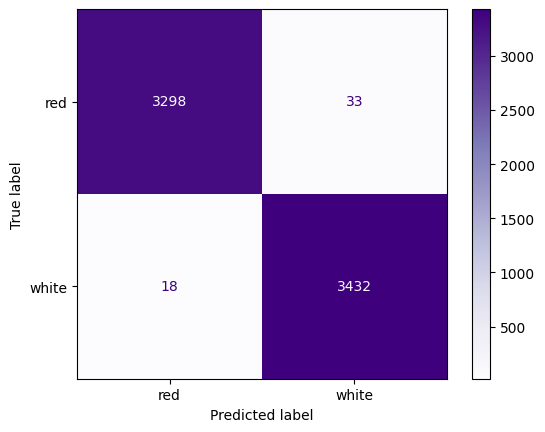

Matriz de KNN


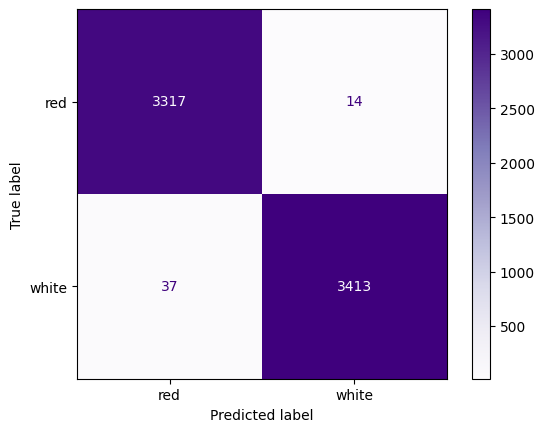

Matriz de Maquina de Soporte Vectorial


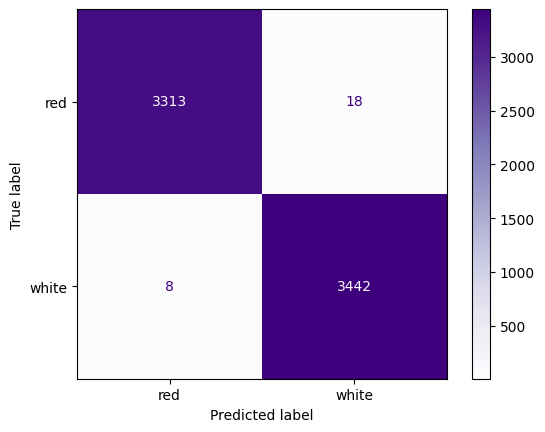

Matriz de Árbol de Decisión


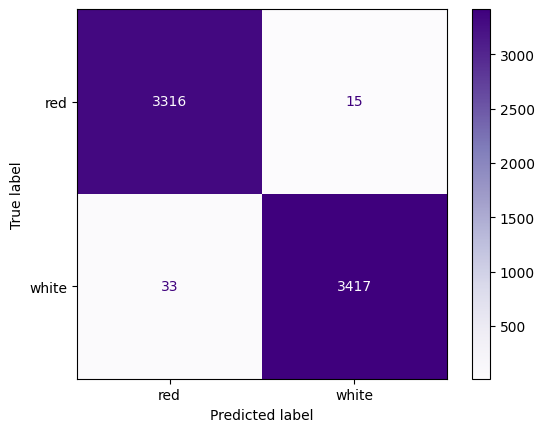

Matriz de Extra Trees


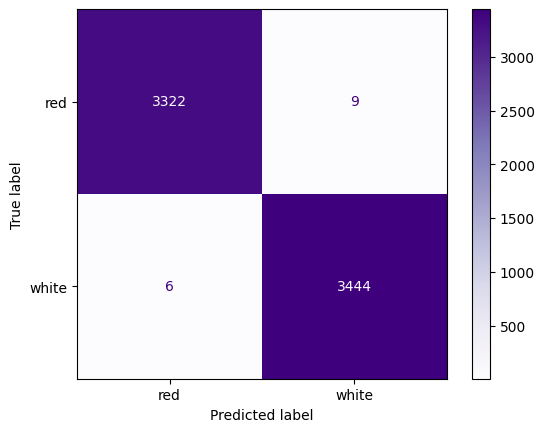

Matriz de Random Forest


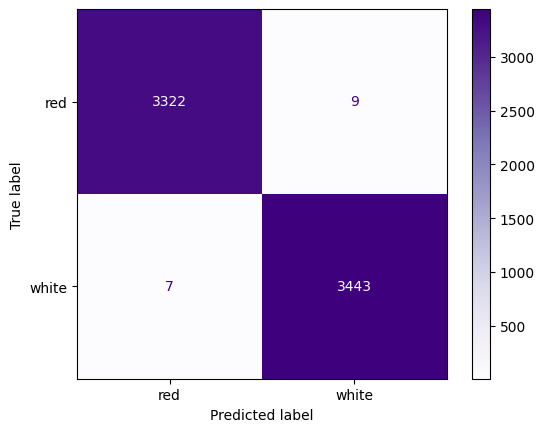

Matriz de Adaptative Boosting


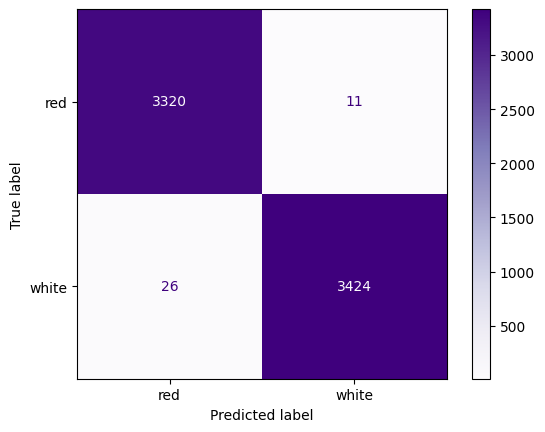

Matriz de Gradient Boosting


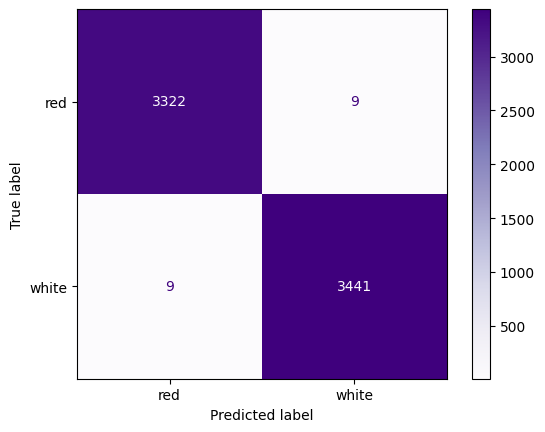

Matriz de Multi Layer Perceptron


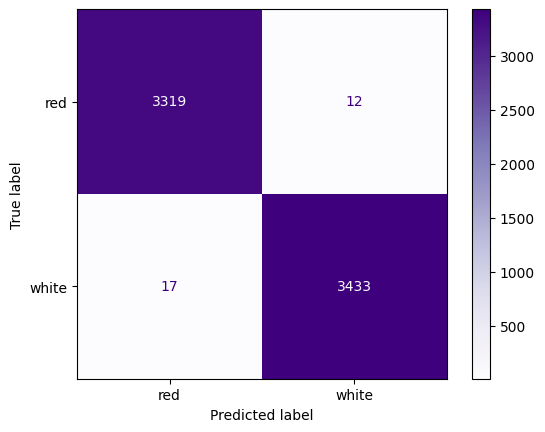

In [77]:
for model in results:
    print(f'Matriz de {model}')
    cm_val = confusion_matrix(results[model]['y_test'], results[model]['y_pred'])
    ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels).plot(cmap=plt.cm.Purples)
    plt.show()

In [92]:
pred_nb = best_clf1.predict(X_testN)
pred_rl = best_clf2.predict(X_testN)
pred_knn = best_clf3.predict(X_testN)
pred_msv = best_clf4.predict(X_testN)
pred_dt = best_clf5.predict(X_testN)
pred_et = best_clf6.predict(X_testN)
pred_rf = best_clf7.predict(X_testN)
pred_ab = best_clf8.predict(X_testN)
pred_gb = best_clf9.predict(X_testN)

model_rna = clf10.best_estimator_
pred_rna = model_rna.predict(X_testN)

In [95]:
def calculo_metricas(y_testN, pred_test, model):
    print(f'Métricas de Desempeño de {model} en Validación')
    print(classification_report(y_testN,pred_test))
    sns.heatmap(confusion_matrix(y_testN, pred_test), annot=True, fmt='d')
    plt.show()

Métricas de Desempeño de Naive Bayes en Validación
              precision    recall  f1-score   support

         red       0.97      0.98      0.98      1513
       white       0.98      0.97      0.98      1394

    accuracy                           0.98      2907
   macro avg       0.98      0.98      0.98      2907
weighted avg       0.98      0.98      0.98      2907



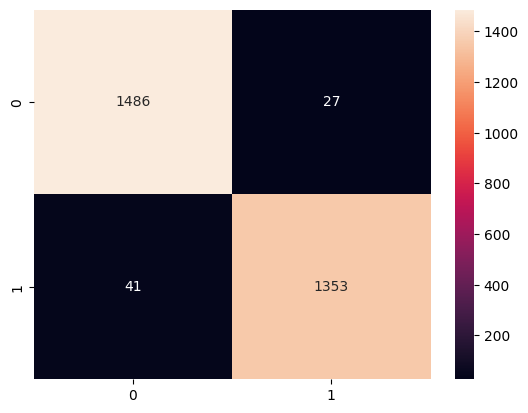

Métricas de Desempeño de Regresión Logística en Validación
              precision    recall  f1-score   support

         red       0.99      0.99      0.99      1513
       white       0.99      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907



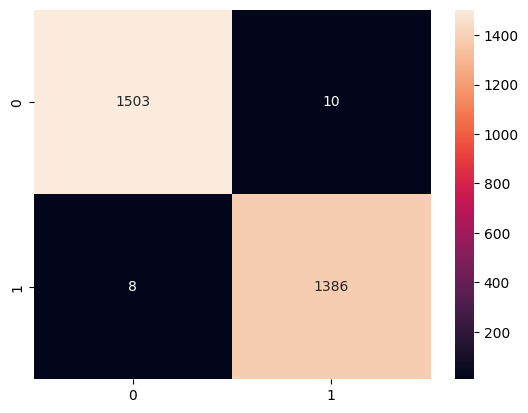

Métricas de Desempeño de K-Vecinos más Cercanos en Validación
              precision    recall  f1-score   support

         red       0.99      1.00      1.00      1513
       white       1.00      0.99      1.00      1394

    accuracy                           1.00      2907
   macro avg       1.00      1.00      1.00      2907
weighted avg       1.00      1.00      1.00      2907



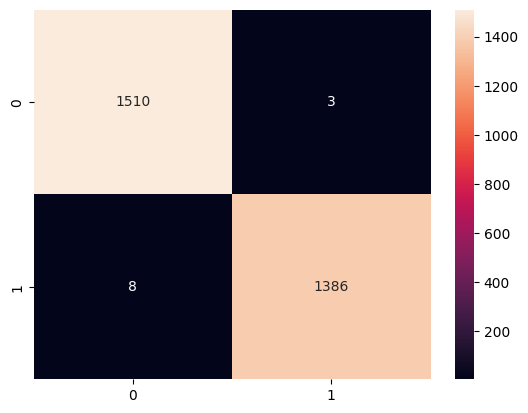

Métricas de Desempeño de Máquina de Soporte Vectorial en Validación
              precision    recall  f1-score   support

         red       1.00      1.00      1.00      1513
       white       0.99      1.00      1.00      1394

    accuracy                           1.00      2907
   macro avg       1.00      1.00      1.00      2907
weighted avg       1.00      1.00      1.00      2907



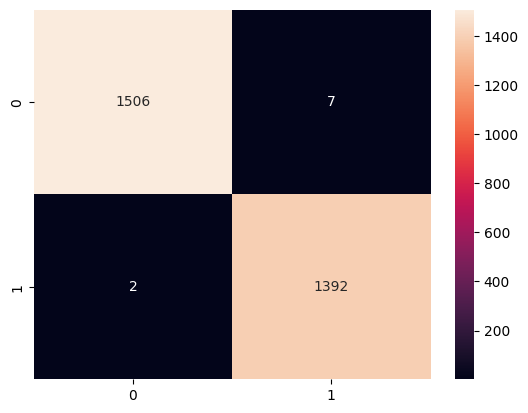

Métricas de Desempeño de Árbol de Desición en Validación
              precision    recall  f1-score   support

         red       0.98      1.00      0.99      1513
       white       1.00      0.98      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907



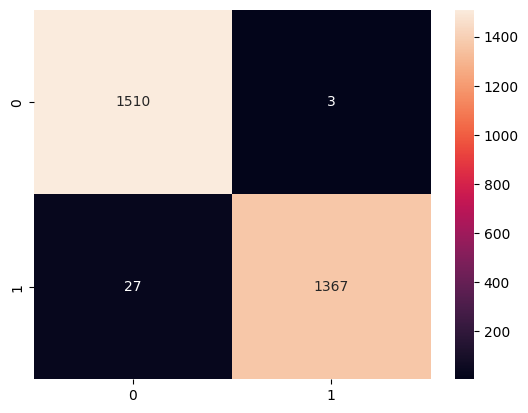

Métricas de Desempeño de Extra Trees en Validación
              precision    recall  f1-score   support

         red       1.00      1.00      1.00      1513
       white       1.00      1.00      1.00      1394

    accuracy                           1.00      2907
   macro avg       1.00      1.00      1.00      2907
weighted avg       1.00      1.00      1.00      2907



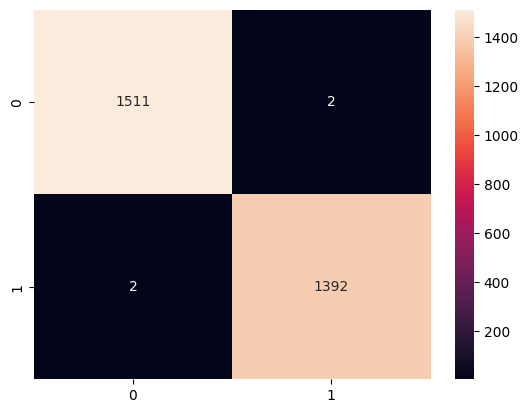

Métricas de Desempeño de Random Forest en Validación
              precision    recall  f1-score   support

         red       1.00      1.00      1.00      1513
       white       1.00      1.00      1.00      1394

    accuracy                           1.00      2907
   macro avg       1.00      1.00      1.00      2907
weighted avg       1.00      1.00      1.00      2907



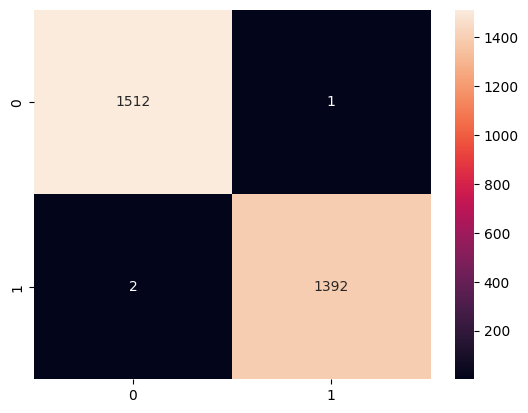

Métricas de Desempeño de Adaptative Boosting en Validación
              precision    recall  f1-score   support

         red       1.00      1.00      1.00      1513
       white       1.00      1.00      1.00      1394

    accuracy                           1.00      2907
   macro avg       1.00      1.00      1.00      2907
weighted avg       1.00      1.00      1.00      2907



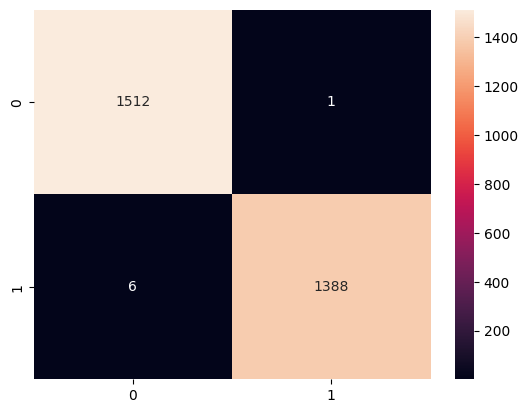

Métricas de Desempeño de Gradient Boosting en Validación
              precision    recall  f1-score   support

         red       1.00      1.00      1.00      1513
       white       1.00      1.00      1.00      1394

    accuracy                           1.00      2907
   macro avg       1.00      1.00      1.00      2907
weighted avg       1.00      1.00      1.00      2907



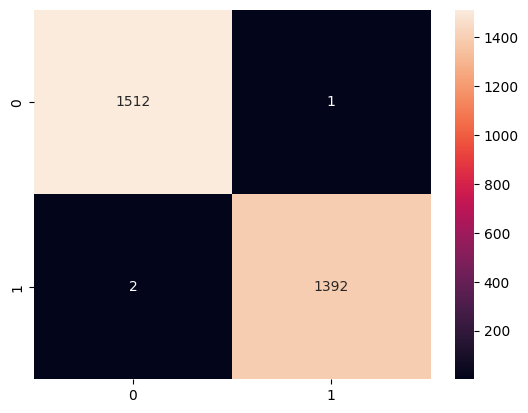

Métricas de Desempeño de Red Neuronal Artificial en Validación
              precision    recall  f1-score   support

         red       0.99      1.00      1.00      1513
       white       1.00      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907



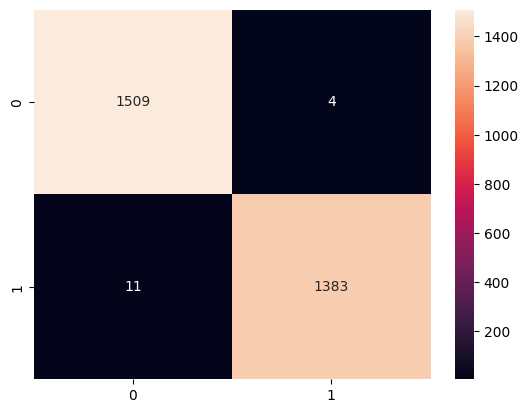

In [96]:
calculo_metricas(y_testN, pred_nb, 'Naive Bayes')
calculo_metricas(y_testN, pred_rl, 'Regresión Logística')
calculo_metricas(y_testN, pred_knn, 'K-Vecinos más Cercanos')
calculo_metricas(y_testN, pred_msv, 'Máquina de Soporte Vectorial')
calculo_metricas(y_testN, pred_dt, 'Árbol de Desición')
calculo_metricas(y_testN, pred_et, 'Extra Trees')
calculo_metricas(y_testN, pred_rf, 'Random Forest')
calculo_metricas(y_testN, pred_ab, 'Adaptative Boosting')
calculo_metricas(y_testN, pred_gb, 'Gradient Boosting')
calculo_metricas(y_testN, pred_rna, 'Red Neuronal Artificial')



## Mejores modelos seleccionados
Nos quedaremos con los modelos que mejor se desempeñaron, en nuestro caso:
- Extra trees
- Random Forest
- Gradient Boosting

## Selección de rasgos
Probaremos diferentes metodos de selección de rasgos con nuestro dataset, para determinar cuales rasgos entregan más eficiencia computacional y desempeño.

In [110]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, mutual_info_classif,
    RFECV, SelectFromModel, SequentialFeatureSelector
)
from sklearn import metrics
import warnings

warnings.filterwarnings("ignore")

feature_names = X_trainN.columns

# Subconjunto interno para decidir hiperparámetros de selección, como el número k de rasgos.
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_trainN, y_trainN, test_size=0.25, stratify=y_trainN, random_state=32
)

def modelo_evaluacion():
    return GradientBoostingClassifier(n_estimators=20, random_state=32)

def calcular_metricas(y_real, y_pred):
    return {
        "Accuracy": metrics.accuracy_score(y_real['type'].tolist(), y_pred),
        "F1 macro": metrics.f1_score(y_real['type'].tolist(), y_pred, average="macro")
    }

def evaluar_features_en_validacion(features):
    model = modelo_evaluacion()
    model.fit(X_subtrain[features], y_subtrain)
    pred_val = model.predict(X_val[features])
    return calcular_metricas(y_val, pred_val)

def evaluar_features_en_test(features):
    model = modelo_evaluacion()
    model.fit(X_trainN[features], y_trainN)
    pred_test = model.predict(X_testN[features])
    return calcular_metricas(y_testN, pred_test)

def seleccionar_mejor_k_desde_ranking(nombre, ranking_features):
    filas = []
    for k in range(1, len(ranking_features) + 1):
        feats = list(ranking_features[:k])
        met = evaluar_features_en_validacion(feats)
        filas.append({
            "Método": nombre,
            "k": k,
            "Rasgos": feats,
            "Accuracy validación": met["Accuracy"],
            "F1 macro validación": met["F1 macro"]
        })
    df_k = pd.DataFrame(filas)
    mejor = df_k.sort_values(
        by=["F1 macro validación", "Accuracy validación"],
        ascending=False
    ).iloc[0]
    return list(mejor["Rasgos"]), df_k

print("Entrenamiento:", X_trainN.shape)
print("Validación interna:", X_val.shape)
print("Prueba final:", X_testN.shape)


Entrenamiento: (6781, 12)
Validación interna: (1696, 12)
Prueba final: (2907, 12)


In [112]:
#Modelo 1: Todos los rasgos
feature_sets_previos = {}
curvas_validacion_previas = {}

feature_sets_previos["Todos los rasgos"] = list(feature_names)

In [113]:
#Modelo 2: selectKBest con ANOVA
anova_selector = SelectKBest(score_func=f_classif, k="all")
anova_selector.fit(X_subtrain, y_subtrain)
anova_ranking = pd.Series(anova_selector.scores_, index=feature_names).sort_values(ascending=False).index
feature_sets_previos["SelectKBest ANOVA"] , curvas_validacion_previas["SelectKBest ANOVA"] = seleccionar_mejor_k_desde_ranking("SelectKBest ANOVA", anova_ranking)

In [114]:
#Modelo 3: selectKBest con chi2
chi2_selector = SelectKBest(score_func=chi2, k="all")
chi2_selector.fit(X_subtrain, y_subtrain)
chi2_ranking = pd.Series(chi2_selector.scores_, index=feature_names).sort_values(ascending=False).index
feature_sets_previos["SelectKBest Chi2"], curvas_validacion_previas["SelectKBest Chi2"] = seleccionar_mejor_k_desde_ranking("SelectKBest Chi2", chi2_ranking)

In [115]:
#Modelo 4: SelectKBest con informacion mutua
mi_scores = mutual_info_classif(X_subtrain, y_subtrain, random_state=32)
mi_ranking = pd.Series(mi_scores, index=feature_names).sort_values(ascending=False).index
feature_sets_previos["Información mutua"], curvas_validacion_previas["Información mutua"] = seleccionar_mejor_k_desde_ranking("Información mutua", mi_ranking)

In [116]:
#Modelo 5: Forward Selection
filas_sfs = []
for k in range(1, len(feature_names)):
    sfs = SequentialFeatureSelector(
        LogisticRegression(max_iter=2000, class_weight="balanced"),
        n_features_to_select=k,
        direction="forward",
        scoring="f1",
        cv=5,
        n_jobs=-1
    )

    pipe_sfs = Pipeline([
        ("scale", StandardScaler()),
        ("sfs", sfs)
    ])

    pipe_sfs.fit(X_subtrain, y_subtrain)
    selected = list(feature_names[pipe_sfs.named_steps["sfs"].get_support()])
    met = evaluar_features_en_validacion(selected)

    filas_sfs.append({
        "Método": "Forward Selection",
        "k": k,
        "Rasgos": selected,
        "Accuracy validación": met["Accuracy"],
        "F1 macro validación": met["F1 macro"]
    })

curvas_validacion_previas["Forward Selection"] = pd.DataFrame(filas_sfs)
mejor_sfs = curvas_validacion_previas["Forward Selection"].sort_values(
    by=["F1 macro validación", "Accuracy validación"],
    ascending=False
).iloc[0]
feature_sets_previos["Forward Selection"] = list(mejor_sfs["Rasgos"])

In [117]:
#Modelo 6: RFECV
rfecv = RFECV(
    estimator=LogisticRegression(max_iter=2000, class_weight="balanced"),
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=32),
    scoring="f1_macro",
    min_features_to_select=1,
    n_jobs=-1
)

pipe_rfecv = Pipeline([
    ("scale", StandardScaler()),
    ("rfecv", rfecv)
])

pipe_rfecv.fit(X_subtrain, y_subtrain)
feature_sets_previos["RFECV"] = list(feature_names[pipe_rfecv.named_steps["rfecv"].support_])

In [118]:
#Modelo 7: Embebida con L1
l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=2000,
    class_weight="balanced",
    random_state=32
)

pipe_l1 = Pipeline([
    ("scale", StandardScaler()),
    ("select", SelectFromModel(l1_model))
])

pipe_l1.fit(X_subtrain, y_subtrain)
mask_l1 = pipe_l1.named_steps["select"].get_support()

if mask_l1.sum() == 0:
    l1_model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1.0,
        max_iter=2000,
        class_weight="balanced",
        random_state=32
    )
    pipe_l1 = Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectFromModel(l1_model))
    ])
    pipe_l1.fit(X_subtrain, y_subtrain)
    mask_l1 = pipe_l1.named_steps["select"].get_support()

feature_sets_previos["L1 embebido"] = list(feature_names[mask_l1])

In [119]:
#Modelo 8: Importancia con Gradient Boosting
gb_selector = GradientBoostingClassifier(n_estimators=20, random_state=32)
gb_selector.fit(X_subtrain, y_subtrain)
gb_ranking = pd.Series(gb_selector.feature_importances_, index=feature_names).sort_values(ascending=False).index
feature_sets_previos["Importancia Gradient Boosting"], curvas_validacion_previas["Importancia Gradient Boosting"] = seleccionar_mejor_k_desde_ranking("Importancia Gradient Boosting", gb_ranking)

print(feature_sets_previos)

{'Todos los rasgos': ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality'], 'SelectKBest ANOVA': ['total sulfur dioxide', 'volatile acidity', 'free sulfur dioxide', 'sulphates', 'chlorides', 'density', 'fixed acidity', 'residual sugar'], 'SelectKBest Chi2': ['total sulfur dioxide', 'free sulfur dioxide', 'volatile acidity', 'residual sugar', 'sulphates', 'chlorides', 'fixed acidity'], 'Información mutua': ['chlorides', 'total sulfur dioxide', 'residual sugar', 'volatile acidity', 'density', 'free sulfur dioxide', 'sulphates', 'fixed acidity'], 'Forward Selection': ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH'], 'RFECV': ['fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'sulphates', 'a

In [120]:
resultados_previos = []

for metodo, feats in feature_sets_previos.items():
    met = evaluar_features_en_test(feats)
    resultados_previos.append({
        "Método": metodo,
        "Número de rasgos": len(feats),
        "Rasgos seleccionados": feats,
        "Accuracy prueba": met["Accuracy"],
        "F1 macro prueba": met["F1 macro"]
    })

benchmark_prev_df = (
    pd.DataFrame(resultados_previos).sort_values(by=["F1 macro prueba", "Accuracy prueba"], ascending=False).reset_index(drop=True))

benchmark_prev_df


,Método,Número de rasgos,Rasgos seleccionados,Accuracy prueba,F1 macro prueba
0,SelectKBest ANOVA,8,"[total sulfur dioxide, volatile acidity, free ...",0.982112,0.982084
1,Información mutua,8,"[chlorides, total sulfur dioxide, residual sug...",0.982112,0.982084
2,Todos los rasgos,12,"[fixed acidity, volatile acidity, citric acid,...",0.980736,0.980708
3,L1 embebido,10,"[volatile acidity, residual sugar, chlorides, ...",0.980048,0.980018
4,Forward Selection,9,"[fixed acidity, volatile acidity, citric acid,...",0.979704,0.979672
5,RFECV,9,"[fixed acidity, volatile acidity, residual sug...",0.979360,0.979335
6,Importancia Gradient Boosting,5,"[chlorides, total sulfur dioxide, volatile aci...",0.978672,0.978645
7,SelectKBest Chi2,7,"[total sulfur dioxide, free sulfur dioxide, vo...",0.977984,0.977953


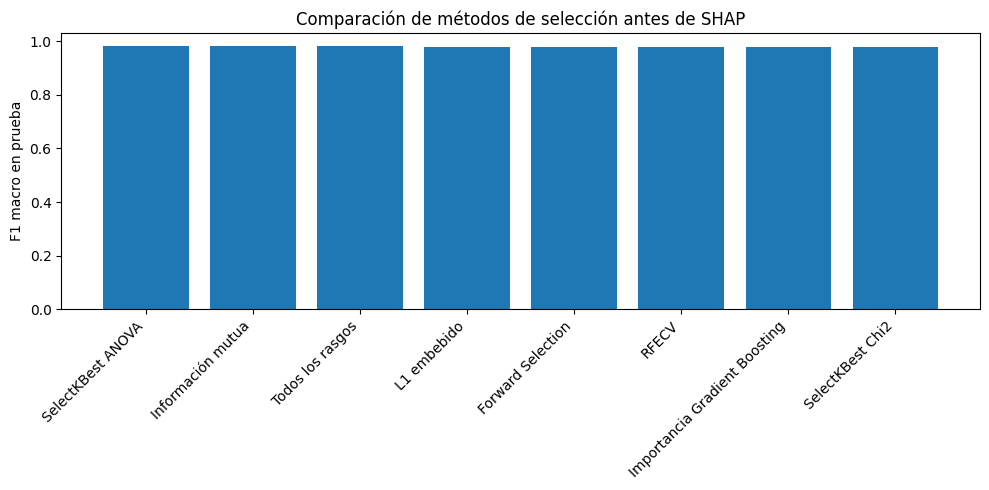

In [121]:
plt.figure(figsize=(10, 5))
plt.bar(benchmark_prev_df["Método"], benchmark_prev_df["F1 macro prueba"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 macro en prueba")
plt.title("Comparación de métodos de selección antes de SHAP")
plt.tight_layout()
plt.show()

In [122]:
from collections import Counter

contador_rasgos = Counter()

for metodo, feats in feature_sets_previos.items():
    if metodo != "Todos los rasgos":
        contador_rasgos.update(feats)

estabilidad_rasgos = (
    pd.DataFrame(contador_rasgos.items(), columns=["Rasgo", "Número de métodos que lo seleccionan"])
      .sort_values(by="Número de métodos que lo seleccionan", ascending=False)
      .reset_index(drop=True)
)

estabilidad_rasgos

,Rasgo,Número de métodos que lo seleccionan
0,total sulfur dioxide,7
1,volatile acidity,7
2,chlorides,7
3,free sulfur dioxide,6
4,sulphates,6
5,density,6
6,residual sugar,6
7,fixed acidity,5
8,pH,2
9,alcohol,2


## SHAP

In [100]:
%pip install shap -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: C:\Users\olgam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [101]:
import shap

In [123]:
gb_all = GradientBoostingClassifier(n_estimators=20, random_state=42)
gb_all.fit(X_trainN, y_trainN)

pred_all = gb_all.predict(X_testN)

baseline_acc = metrics.accuracy_score(y_testN, pred_all)
baseline_f1_macro = metrics.f1_score(y_testN, pred_all, average="macro")

print("Modelo con todos los rasgos")
print("Accuracy:", baseline_acc)
print("F1 macro:", baseline_f1_macro)

Modelo con todos los rasgos
Accuracy: 0.9807361541107671
F1 macro: 0.9807080265189976


In [124]:
gb_shap = GradientBoostingClassifier(n_estimators=20, random_state=32)
gb_shap.fit(X_subtrain, y_subtrain)

explainer = shap.TreeExplainer(gb_shap)
shap_values = explainer(X_subtrain)

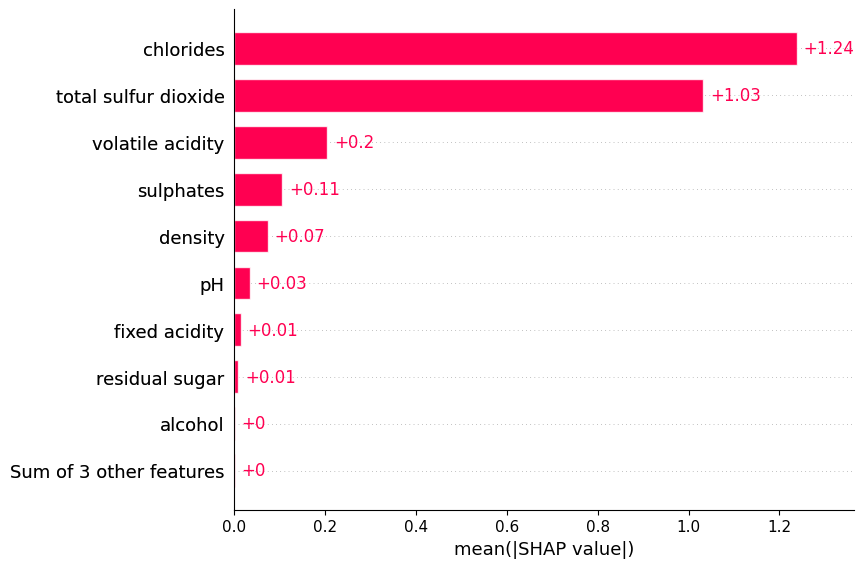

In [125]:
shap.plots.bar(shap_values)

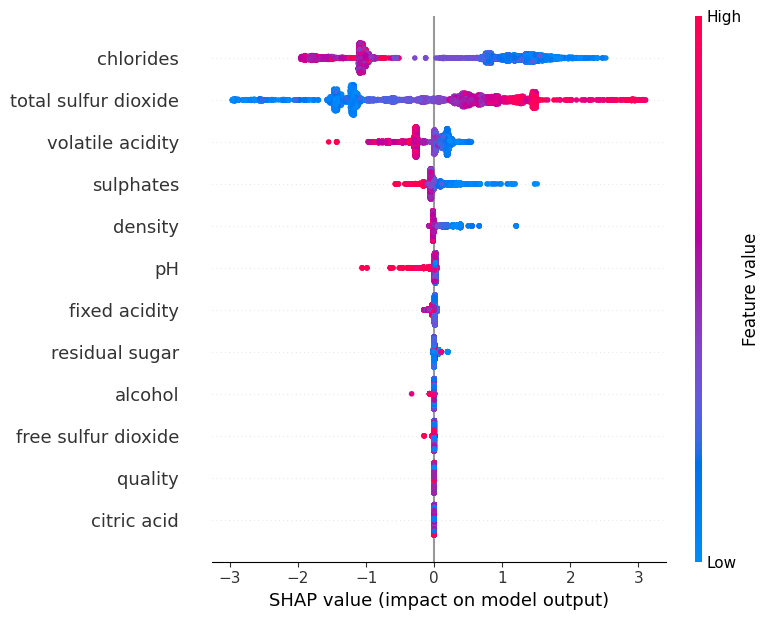

In [126]:
shap.summary_plot(shap_values, features=X_subtrain)

In [127]:
values = shap_values.values
shap_importance = np.abs(values).mean(axis=0)

feature_importance_shap = (pd.Series(shap_importance, index=feature_names).sort_values(ascending=False))

feature_importance_shap

chlorides               1.237833
total sulfur dioxide    1.032862
volatile acidity        0.204665
sulphates               0.105682
density                 0.073810
pH                      0.033729
fixed acidity           0.014011
residual sugar          0.008771
alcohol                 0.001683
free sulfur dioxide     0.000842
citric acid             0.000000
quality                 0.000000
dtype: float64

In [128]:
#Modelo 9: top-k SHAP
ks = range(1, X_trainN.shape[1] + 1)
results = []

for k in ks:
    topk = feature_importance_shap.index[:k]

    gb_k = GradientBoostingClassifier(n_estimators=20, random_state=32)
    gb_k.fit(X_subtrain[topk], y_subtrain)

    pred_val = gb_k.predict(X_val[topk])

    results.append({
        "k": k,
        "rasgos": list(topk),
        "accuracy_val": metrics.accuracy_score(y_val, pred_val),
        "f1_macro_val": metrics.f1_score(y_val, pred_val, average="macro")
    })

results_df = pd.DataFrame(results)
results_df

,k,rasgos,accuracy_val,f1_macro_val
0,1,[chlorides],0.918632,0.918610
1,2,"[chlorides, total sulfur dioxide]",0.971108,0.971096
2,3,"[chlorides, total sulfur dioxide, volatile aci...",0.975236,0.975226
3,4,"[chlorides, total sulfur dioxide, volatile aci...",0.975236,0.975221
4,5,"[chlorides, total sulfur dioxide, volatile aci...",0.978774,0.978762
5,6,"[chlorides, total sulfur dioxide, volatile aci...",0.978184,0.978171
6,7,"[chlorides, total sulfur dioxide, volatile aci...",0.977005,0.976990
7,8,"[chlorides, total sulfur dioxide, volatile aci...",0.978184,0.978171
8,9,"[chlorides, total sulfur dioxide, volatile aci...",0.978184,0.978171
9,10,"[chlorides, total sulfur dioxide, volatile aci...",0.978184,0.978171


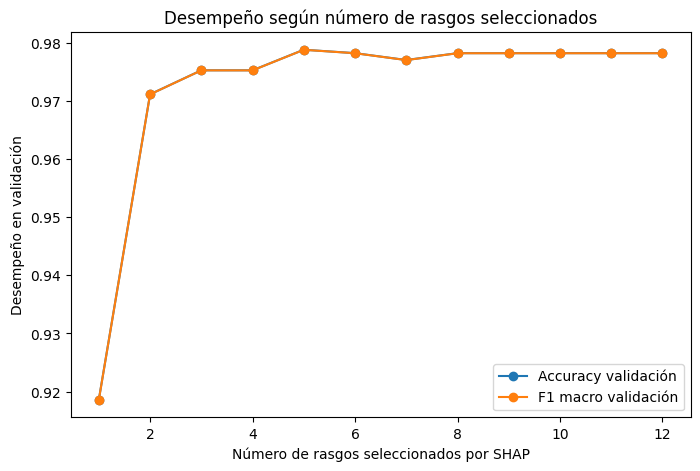

In [129]:
#Visualizacion grafica
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["accuracy_val"], marker="o", label="Accuracy validación")
plt.plot(results_df["k"], results_df["f1_macro_val"], marker="o", label="F1 macro validación")

plt.xlabel("Número de rasgos seleccionados por SHAP")
plt.ylabel("Desempeño en validación")
plt.title("Desempeño según número de rasgos seleccionados")
plt.legend()
plt.show()

In [130]:
best_row = results_df.sort_values(
    by=["f1_macro_val", "accuracy_val"], ascending=False
).iloc[0]

best_k = int(best_row["k"])
best_features = feature_importance_shap.index[:best_k]

print("Mejor k según validación:", best_k)
print("Rasgos seleccionados:", list(best_features))
print("F1 macro validación:", best_row["f1_macro_val"])
print("Accuracy validación:", best_row["accuracy_val"])

Mejor k según validación: 5
Rasgos seleccionados: ['chlorides', 'total sulfur dioxide', 'volatile acidity', 'sulphates', 'density']
F1 macro validación: 0.9787617711881387
Accuracy validación: 0.9787735849056604


In [131]:
gb_final_shap = GradientBoostingClassifier(n_estimators=20, random_state=42)
gb_final_shap.fit(X_trainN[best_features], y_trainN)

pred_shap = gb_final_shap.predict(X_testN[best_features])

shap_acc = metrics.accuracy_score(y_testN, pred_shap)
shap_f1_macro = metrics.f1_score(y_testN, pred_shap, average="macro")

comparison_df = pd.DataFrame({
    "Método": ["Todos los rasgos", "SHAP top-k"],
    "Número de rasgos": [X_trainN.shape[1], len(best_features)],
    "Rasgos seleccionados": [list(feature_names), list(best_features)],
    "Accuracy prueba": [baseline_acc, shap_acc],
    "F1 macro prueba": [baseline_f1_macro, shap_f1_macro]
})

comparison_df

,Método,Número de rasgos,Rasgos seleccionados,Accuracy prueba,F1 macro prueba
0,Todos los rasgos,12,"[fixed acidity, volatile acidity, citric acid,...",0.980736,0.980708
1,SHAP top-k,5,"[chlorides, total sulfur dioxide, volatile aci...",0.978672,0.978645


In [132]:
#Modelo 10: Importancia acumulada con SHAP
cum_importance = (feature_importance_shap / feature_importance_shap.sum()).cumsum()
selected_by_cum = cum_importance[cum_importance <= 0.95].index

# Si el primer rasgo supera el umbral, se conserva al menos un rasgo.
if len(selected_by_cum) == 0:
    selected_by_cum = feature_importance_shap.index[:1]

print("Rasgos seleccionados por importancia acumulada:")
print(list(selected_by_cum))
print("Importancia acumulada:", cum_importance.loc[selected_by_cum[-1]])

Rasgos seleccionados por importancia acumulada:
['chlorides', 'total sulfur dioxide', 'volatile acidity']
Importancia acumulada: 0.9121082384582161


In [133]:
gb_cum = GradientBoostingClassifier(n_estimators=20, random_state=42)
gb_cum.fit(X_trainN[selected_by_cum], y_trainN)

pred_cum = gb_cum.predict(X_testN[selected_by_cum])

comparison_cum_df = pd.DataFrame({
    "Método": ["Todos los rasgos", "SHAP top-k", "SHAP 95% acumulado"],
    "Número de rasgos": [X_trainN.shape[1], len(best_features), len(selected_by_cum)],
    "Rasgos seleccionados": [list(feature_names), list(best_features), list(selected_by_cum)],
    "Accuracy prueba": [
        baseline_acc,
        shap_acc,
        metrics.accuracy_score(y_testN, pred_cum)
    ],
    "F1 macro prueba": [
        baseline_f1_macro,
        shap_f1_macro,
        metrics.f1_score(y_testN, pred_cum, average="macro")
    ]
})

comparison_cum_df


,Método,Número de rasgos,Rasgos seleccionados,Accuracy prueba,F1 macro prueba
0,Todos los rasgos,12,"[fixed acidity, volatile acidity, citric acid,...",0.980736,0.980708
1,SHAP top-k,5,"[chlorides, total sulfur dioxide, volatile aci...",0.978672,0.978645
2,SHAP 95% acumulado,3,"[chlorides, total sulfur dioxide, volatile aci...",0.974888,0.974851


In [134]:
if "benchmark_prev_df" in globals():
    shap_rows = comparison_cum_df[comparison_cum_df["Método"] != "Todos los rasgos"]

    benchmark_global_df = (
        pd.concat([benchmark_prev_df, shap_rows], ignore_index=True)
          .drop_duplicates(subset=["Método"], keep="last")
          .sort_values(by=["F1 macro prueba", "Accuracy prueba"], ascending=False)
          .reset_index(drop=True)
    )
else:
    benchmark_global_df = comparison_cum_df.sort_values(
        by=["F1 macro prueba", "Accuracy prueba"],
        ascending=False
    ).reset_index(drop=True)

benchmark_global_df

,Método,Número de rasgos,Rasgos seleccionados,Accuracy prueba,F1 macro prueba
0,SelectKBest ANOVA,8,"[total sulfur dioxide, volatile acidity, free ...",0.982112,0.982084
1,Información mutua,8,"[chlorides, total sulfur dioxide, residual sug...",0.982112,0.982084
2,Todos los rasgos,12,"[fixed acidity, volatile acidity, citric acid,...",0.980736,0.980708
3,L1 embebido,10,"[volatile acidity, residual sugar, chlorides, ...",0.980048,0.980018
4,Forward Selection,9,"[fixed acidity, volatile acidity, citric acid,...",0.979704,0.979672
5,RFECV,9,"[fixed acidity, volatile acidity, residual sug...",0.979360,0.979335
6,Importancia Gradient Boosting,5,"[chlorides, total sulfur dioxide, volatile aci...",0.978672,0.978645
7,SHAP top-k,5,"[chlorides, total sulfur dioxide, volatile aci...",0.978672,0.978645
8,SelectKBest Chi2,7,"[total sulfur dioxide, free sulfur dioxide, vo...",0.977984,0.977953
9,SHAP 95% acumulado,3,"[chlorides, total sulfur dioxide, volatile aci...",0.974888,0.974851


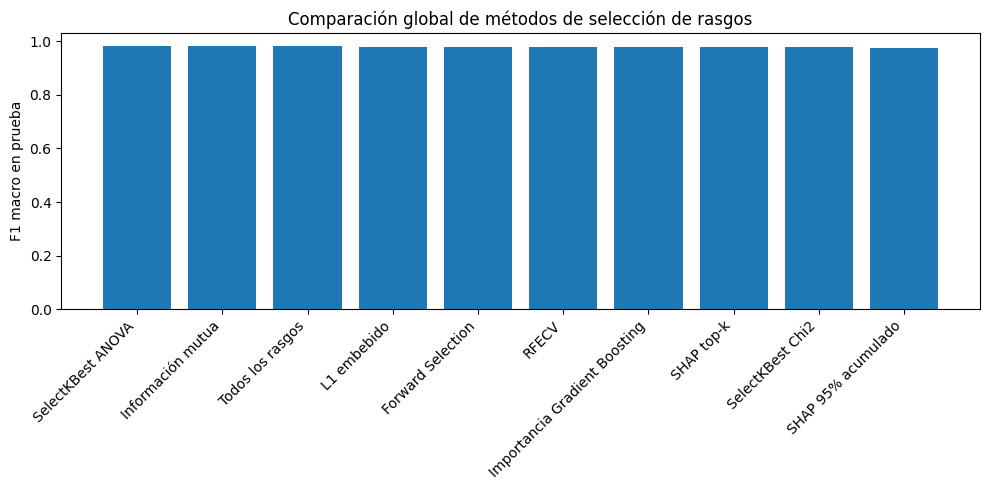

In [135]:
plt.figure(figsize=(10, 5))
plt.bar(benchmark_global_df["Método"], benchmark_global_df["F1 macro prueba"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 macro en prueba")
plt.title("Comparación global de métodos de selección de rasgos")
plt.tight_layout()
plt.show()

## ¿Qué rasgos seleccionar?

Todos dieron practicamente el mismo f1_score, entonces podemos definir que sea uno que use tantos pocos rasgos, y los rasgos mas representativos, mínimo:
- Total sulfur Dioxide
- chlorides
- volatile acidity

Posiblemente Importancia Gradient Boosting ó SHAP top-k. Revisaremos sus rasgos elegidos.

In [136]:
print("Rasgos seleccionados por Importancia Gradient Boosting")
list(benchmark_global_df[benchmark_global_df['Método'] == 'Importancia Gradient Boosting']['Rasgos seleccionados'])

Rasgos seleccionados por Importancia Gradient Boosting


[['chlorides',
  'total sulfur dioxide',
  'volatile acidity',
  'sulphates',
  'density']]

In [137]:
print("Rasgos seleccionados por Importancia Gradient Boosting")
list(benchmark_global_df[benchmark_global_df['Método'] == 'SHAP top-k']['Rasgos seleccionados'])

Rasgos seleccionados por Importancia Gradient Boosting


[['chlorides',
  'total sulfur dioxide',
  'volatile acidity',
  'sulphates',
  'density']]

Teniendo los mismos rasgos, seleccionamos SHAP top-k

## Reentreno de los 3 mejores modelos
Con esos rasgos, reentrenaremos los 3 mejores modelos para verificar si podemos mejorar el desempeño de clasificacion sin llegar al sobreajuste.

In [138]:
X_trainN.drop(columns=['fixed acidity','citric acid','residual sugar','free sulfur dioxide','alcohol','quality'], inplace=True)
X_testN.drop(columns=['fixed acidity','citric acid','residual sugar','free sulfur dioxide','alcohol','quality'], inplace=True)

X_trainN

,volatile acidity,chlorides,total sulfur dioxide,density,pH,sulphates
6159,0.220000,0.167774,0.091716,0.438551,0.341085,0.321429
5064,0.273333,0.377076,0.242604,0.417853,0.302326,0.414286
531,0.106667,0.059801,0.162722,0.210867,0.457364,0.228571
1946,0.086667,0.063123,0.319527,0.301423,0.310078,0.092857
1156,0.100000,0.058140,0.316568,0.288486,0.387597,0.285714
...,...,...,...,...,...,...
3143,0.046667,0.069767,0.272189,0.306598,0.294574,0.157143
8444,0.310000,0.098007,0.085799,0.383355,0.480620,0.278571
7571,0.193333,0.134551,0.153846,0.469599,0.480620,0.342857
4030,0.113333,0.068106,0.325444,0.379905,0.294574,0.200000


In [139]:
X_testN

,volatile acidity,chlorides,total sulfur dioxide,density,pH,sulphates
3201,0.093333,0.043189,0.399408,0.177663,0.302326,0.078571
7434,0.393333,0.122924,0.062130,0.455800,0.558140,0.228571
7013,0.253333,0.137874,0.112426,0.469599,0.310078,0.371429
5324,0.213333,0.245847,0.115385,0.438120,0.457364,0.492857
3582,0.160000,0.053156,0.538462,0.467012,0.217054,0.228571
...,...,...,...,...,...,...
9267,0.310000,0.129568,0.162722,0.404916,0.496124,0.321429
6868,0.200000,0.204319,0.014793,0.373437,0.395349,0.250000
8362,0.266667,0.107973,0.171598,0.352738,0.310078,0.192857
4348,0.126667,0.073090,0.494083,0.426046,0.302326,0.271429


In [140]:
model_rf_sr = RandomForestClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None,5,10,20,30,50,60],
    'min_samples_split': [2,4,6],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf_rf_sr = GridSearchCV(estimator=model_rf_sr,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf_rf_sr.fit(X_trainN, y_trainN)

,estimator,RandomForestC...ndom_state=32)
,param_grid,"{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...], ...}"
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,400


In [141]:
cv_results = pd.DataFrame(clf_rf_sr.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,param_n_estimators,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
674,5.757149,0.298809,0.297196,0.037917,gini,10,None,2,400,"{'criterion': 'gini', 'max_depth': 10, 'max_le...",...,0.001267,1,0.997051,0.997787,0.996311,0.995574,0.999262,0.997197,0.001269,1
337,2.913848,0.189847,0.198297,0.017557,entropy,14,None,2,200,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001228,2,0.996314,0.998525,0.996311,0.995574,0.998525,0.997050,0.001234,2
1177,3.000771,0.340576,0.200282,0.015729,log_loss,14,None,2,200,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001228,2,0.996314,0.998525,0.996311,0.995574,0.998525,0.997050,0.001234,2
675,7.033970,0.656294,0.313552,0.030502,gini,10,None,2,500,"{'criterion': 'gini', 'max_depth': 10, 'max_le...",...,0.001036,4,0.997051,0.997787,0.996311,0.995574,0.998525,0.997050,0.001043,4
1093,3.546235,0.368133,0.242099,0.017525,log_loss,10,None,2,200,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.001036,4,0.997051,0.997787,0.996311,0.995574,0.998525,0.997050,0.001043,4
1094,6.804995,0.508032,0.358671,0.074920,log_loss,10,None,2,400,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.001036,4,0.997051,0.997787,0.996311,0.995574,0.998525,0.997050,0.001043,4
255,8.119529,0.603366,0.305274,0.024169,entropy,10,None,2,500,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.001036,4,0.997051,0.997787,0.996311,0.995574,0.998525,0.997050,0.001043,4
254,6.491642,0.250826,0.322386,0.027390,entropy,10,None,2,400,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.001036,4,0.997051,0.997787,0.996311,0.995574,0.998525,0.997050,0.001043,4
253,3.031930,0.071236,0.200871,0.026099,entropy,10,None,2,200,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.001036,4,0.997051,0.997787,0.996311,0.995574,0.998525,0.997050,0.001043,4
1095,8.368114,0.885767,0.375088,0.047494,log_loss,10,None,2,500,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.001036,4,0.997051,0.997787,0.996311,0.995574,0.998525,0.997050,0.001043,4


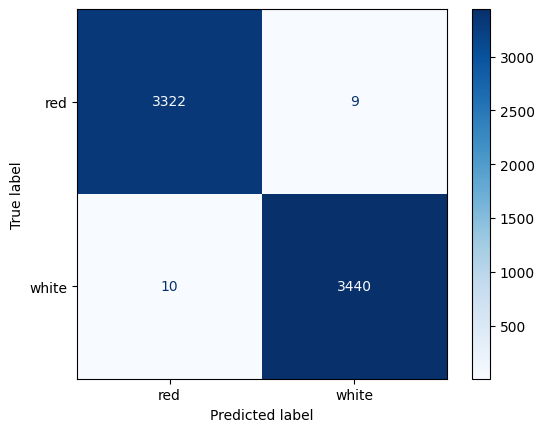

In [142]:
labels = data['type'].unique()

best_clf_rf_sr = clf_rf_sr.best_estimator_
y_train_pred = cross_val_predict(best_clf_rf_sr, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val = confusion_matrix(y_trainN, y_train_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels).plot(cmap=plt.cm.Blues)

In [143]:
model_gb_sr = GradientBoostingClassifier(random_state=32)
param_grid = {
    'criterion': ['friedman_mse', 'squared_error'],
    'max_depth': [5,7,9,12],
    'max_leaf_nodes': [10,40,None],
    'min_samples_split': [2,3],
    'n_estimators': [100,200,300,400]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf_gb_sr = RandomizedSearchCV(estimator= model_gb_sr, param_distributions=param_grid, cv=cv, scoring=scoring,
                          refit='f1_macro',
                          n_jobs=-1, n_iter=96)
clf_gb_sr.fit(X_trainN, y_trainN)

,estimator,GradientBoost...ndom_state=32)
,param_distributions,"{'criterion': ['friedman_mse', 'squared_error'], 'max_depth': [5, 7, ...], 'max_leaf_nodes': [10, 40, ...], 'min_samples_split': [2, 3], ...}"
,n_iter,96
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [144]:
cv_results = pd.DataFrame(clf_gb_sr.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_leaf_nodes,param_max_depth,param_criterion,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
92,12.743376,0.588854,0.154184,0.012462,300,3,None,7,squared_error,"{'n_estimators': 300, 'min_samples_split': 3, ...",...,0.001817,1,0.995577,0.994836,0.997049,0.994099,0.999262,0.996165,0.001831,1
34,8.087971,0.807906,0.156472,0.027195,200,3,40,9,squared_error,"{'n_estimators': 200, 'min_samples_split': 3, ...",...,0.001706,2,0.995577,0.996312,0.997049,0.993361,0.998525,0.996165,0.001708,2
19,8.554919,0.963290,0.145453,0.024202,200,3,40,9,friedman_mse,"{'n_estimators': 200, 'min_samples_split': 3, ...",...,0.001706,2,0.995577,0.996312,0.997049,0.993361,0.998525,0.996165,0.001708,2
67,16.099347,1.320888,0.168898,0.025977,400,2,None,7,friedman_mse,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.001991,2,0.996314,0.994836,0.997049,0.993361,0.999262,0.996165,0.002001,4
82,13.520905,0.297311,0.149357,0.025433,300,2,None,7,friedman_mse,"{'n_estimators': 300, 'min_samples_split': 2, ...",...,0.001991,2,0.996314,0.994836,0.997049,0.993361,0.999262,0.996165,0.002001,4
49,5.748201,0.348162,0.138870,0.025244,200,2,None,5,friedman_mse,"{'n_estimators': 200, 'min_samples_split': 2, ...",...,0.001884,6,0.995577,0.995574,0.996311,0.993362,0.999262,0.996017,0.001901,6
84,15.652677,0.797929,0.178961,0.020454,400,2,40,12,friedman_mse,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.001710,7,0.995577,0.995574,0.997049,0.993361,0.998525,0.996017,0.001720,7
86,10.993674,0.912739,0.131492,0.013136,400,2,None,5,friedman_mse,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.001947,8,0.995577,0.994099,0.997049,0.994099,0.999262,0.996017,0.001957,8
16,14.674879,0.611484,0.163189,0.015597,400,2,40,7,squared_error,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.001774,8,0.996314,0.994836,0.997049,0.993361,0.998525,0.996017,0.001783,9
2,15.265817,1.417108,0.170264,0.028139,400,3,40,12,friedman_mse,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.001774,8,0.996314,0.994836,0.997049,0.993361,0.998525,0.996017,0.001783,9


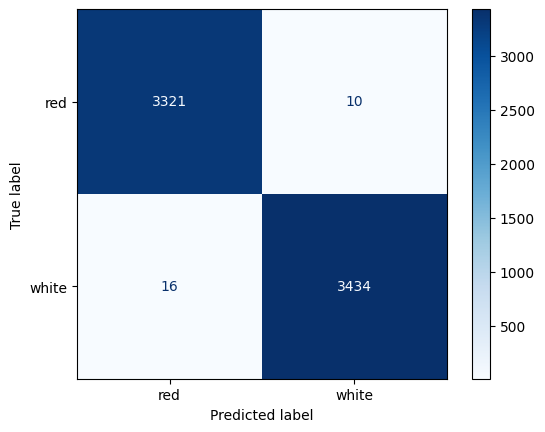

In [145]:
labels = data['type'].unique()

best_clf_gb_sr = clf_gb_sr.best_estimator_
y_train_pred = cross_val_predict(best_clf_gb_sr, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val = confusion_matrix(y_trainN, y_train_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels).plot(cmap=plt.cm.Blues)

In [146]:
model_et_sr = ExtraTreesClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None,5,10,20,30,50,60],
    'min_samples_split': [2,4,6],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf_et_sr = GridSearchCV(estimator=model_et_sr,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf_et_sr.fit(X_trainN, y_trainN)

,estimator,ExtraTreesCla...ndom_state=32)
,param_grid,"{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...], ...}"
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [147]:
cv_results = pd.DataFrame(clf_et_sr.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,param_n_estimators,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
1179,4.413349,0.309382,0.395252,0.042822,log_loss,14,None,2,500,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.002014,1,0.995577,0.997049,0.997787,0.993361,0.999262,0.996607,0.002012,1
339,4.283848,0.132492,0.434215,0.040459,entropy,14,None,2,500,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.002014,1,0.995577,0.997049,0.997787,0.993361,0.999262,0.996607,0.002012,1
759,4.317314,0.339831,0.430022,0.028576,gini,14,None,2,500,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.002255,3,0.995577,0.997049,0.997787,0.992623,0.999262,0.996460,0.002257,3
758,3.715778,0.234657,0.408502,0.053342,gini,14,None,2,400,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.002003,3,0.995577,0.996312,0.997787,0.993361,0.999262,0.996460,0.002001,4
757,1.836309,0.195753,0.303445,0.057429,gini,14,None,2,200,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.002086,5,0.994840,0.996312,0.997787,0.993361,0.999262,0.996312,0.002086,5
338,3.434920,0.205105,0.334905,0.011949,entropy,14,None,2,400,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001923,7,0.995577,0.997049,0.996311,0.993361,0.999262,0.996312,0.001923,6
1178,3.660429,0.165462,0.370310,0.053991,log_loss,14,None,2,400,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001923,7,0.995577,0.997049,0.996311,0.993361,0.999262,0.996312,0.001923,6
337,1.682763,0.113505,0.244307,0.025938,entropy,14,None,2,200,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001923,7,0.995577,0.997049,0.996311,0.993361,0.999262,0.996312,0.001923,6
336,0.877771,0.071267,0.203517,0.017948,entropy,14,None,2,100,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001923,7,0.995577,0.997049,0.996311,0.993361,0.999262,0.996312,0.001923,6
1176,0.836380,0.097235,0.191867,0.020443,log_loss,14,None,2,100,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001923,7,0.995577,0.997049,0.996311,0.993361,0.999262,0.996312,0.001923,6


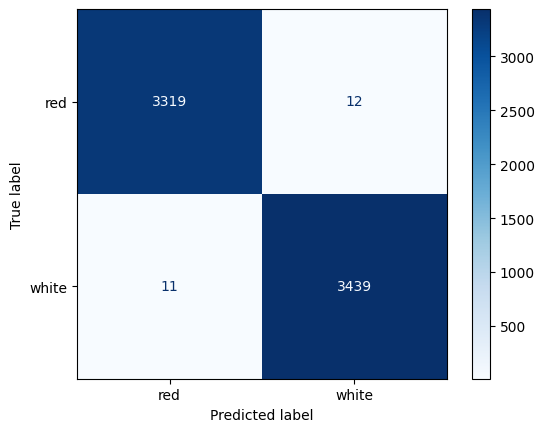

In [148]:
labels = data['type'].unique()

best_clf_et_sr = clf_et_sr.best_estimator_
y_train_pred = cross_val_predict(best_clf_et_sr, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val = confusion_matrix(y_trainN, y_train_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels).plot(cmap=plt.cm.Blues)

In [149]:
strtfdKFold = StratifiedKFold(n_splits=10)
folds = list(strtfdKFold.split(X_trainN, y_trainN))

models = {
    'Extra Trees': clf_et_sr.best_estimator_,
    'Random Forest': clf_rf_sr.best_estimator_,
    'Gradient Boosting': clf_gb_sr.best_estimator_,
}

results = {name: {'accuracy': [], 'f1': [], 'recall': [], 'precision': [],
                  'y_test': [], 'y_pred': []}         
           for name in models}

for model_name, model in models.items():
    for train_index, test_index in folds:
        X_train_cv, X_test_cv = X_trainN.iloc[train_index], X_trainN.iloc[test_index]
        y_train_cv, y_test_cv = y_trainN.iloc[train_index], y_trainN.iloc[test_index]
        
        model.fit(X_train_cv, y_train_cv)
        pred = model.predict(X_test_cv)
        
        results[model_name]['y_test'].extend(y_test_cv['type'].tolist()) 
        results[model_name]['y_pred'].extend(pred)        
        results[model_name]['accuracy'].append(accuracy_score(y_test_cv, pred))
        results[model_name]['f1'].append(f1_score(y_test_cv, pred, average='macro'))
        results[model_name]['recall'].append(recall_score(y_test_cv, pred, average='macro'))
        results[model_name]['precision'].append(precision_score(y_test_cv, pred, average='macro'))

In [150]:
for model in results:
    print(f"f1 de {model}: {np.mean(results[model]['f1'])*100}")

f1 de Extra Trees: 99.64596728293493
f1 de Random Forest: 99.69025332465483
f1 de Gradient Boosting: 99.64599761035198


In [151]:
for model in results:
    print(f"accuracy de {model}: {np.mean(results[model]['accuracy'])*100}")

accuracy de Extra Trees: 99.64608286522345
accuracy de Random Forest: 99.69035237487022
accuracy de Gradient Boosting: 99.64610458725961


In [152]:
for model in results:
    print(f"precision de {model}: {np.mean(results[model]['precision'])*100}")

precision de Extra Trees: 99.64698069291147
precision de Random Forest: 99.69146224549462
precision de Gradient Boosting: 99.64673173028805


In [153]:
for model in results:
    print(f"recall de {model}: {np.mean(results[model]['recall'])*100}")

recall de Extra Trees: 99.64547442521929
recall de Random Forest: 99.69004216400728
recall de Gradient Boosting: 99.64656390313772


Matriz de Extra Trees


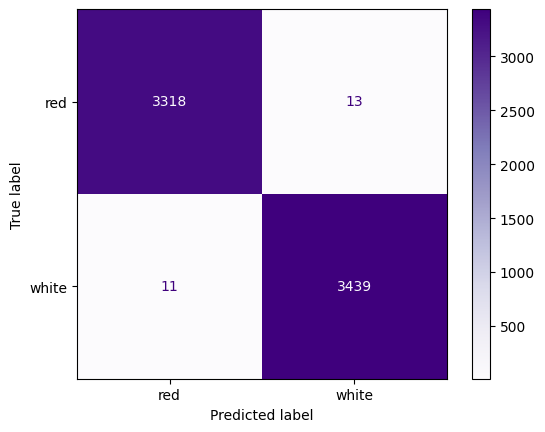

Matriz de Random Forest


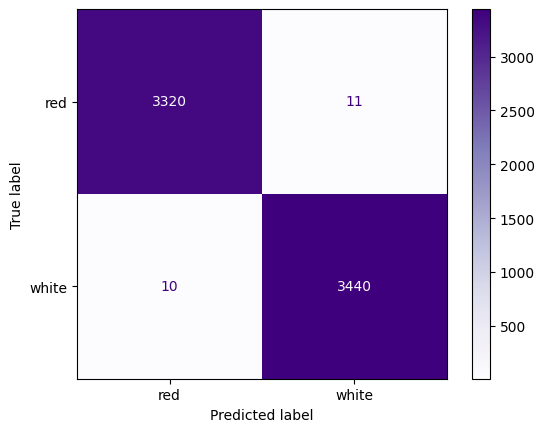

Matriz de Gradient Boosting


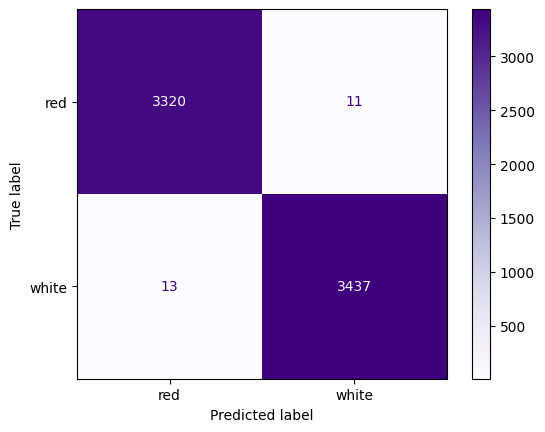

In [154]:
for model in results:
    print(f'Matriz de {model}')
    cm_val = confusion_matrix(results[model]['y_test'], results[model]['y_pred'])
    ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels).plot(cmap=plt.cm.Purples)
    plt.show()

In [155]:
pred_et = best_clf_et_sr.predict(X_testN)
pred_rf = best_clf_rf_sr.predict(X_testN)
pred_gb = best_clf_gb_sr.predict(X_testN)

Métricas de Desempeño de Extra Trees en Validación
              precision    recall  f1-score   support

         red       1.00      1.00      1.00      1513
       white       1.00      1.00      1.00      1394

    accuracy                           1.00      2907
   macro avg       1.00      1.00      1.00      2907
weighted avg       1.00      1.00      1.00      2907



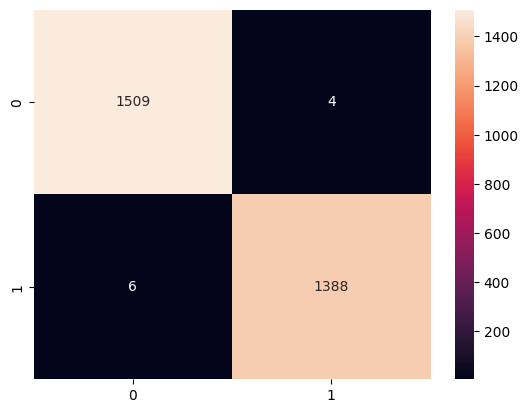

In [156]:
calculo_metricas(y_testN, pred_et, 'Extra Trees')

Métricas de Desempeño de Random Forest en Validación
              precision    recall  f1-score   support

         red       1.00      1.00      1.00      1513
       white       1.00      1.00      1.00      1394

    accuracy                           1.00      2907
   macro avg       1.00      1.00      1.00      2907
weighted avg       1.00      1.00      1.00      2907



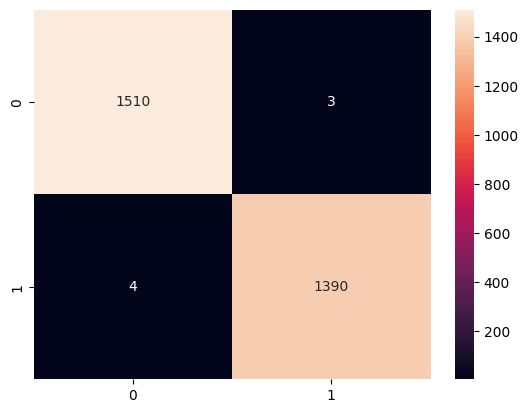

In [157]:
calculo_metricas(y_testN, pred_rf, 'Random Forest')

Métricas de Desempeño de Gradient Boosting en Validación
              precision    recall  f1-score   support

         red       1.00      1.00      1.00      1513
       white       1.00      1.00      1.00      1394

    accuracy                           1.00      2907
   macro avg       1.00      1.00      1.00      2907
weighted avg       1.00      1.00      1.00      2907



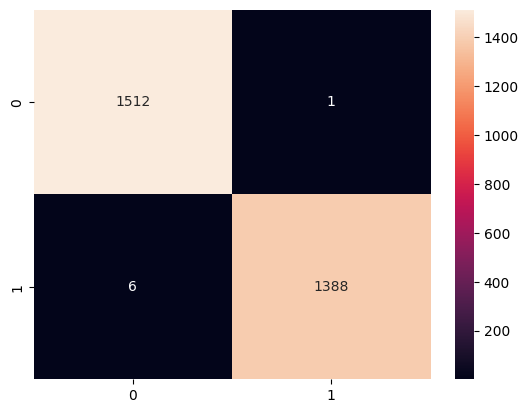

In [158]:
calculo_metricas(y_testN, pred_gb, 'Gradient Boosting')